# CrossAligner: Stage-aware Evaluation of Food-Ontology Semantic Bridges

**Executed analysis notebook — current experimental archive only**

This notebook evaluates the observable CrossAligner pipeline without inventing missing runs or negative labels. It follows the **three research questions used in the paper** and separates Stage&nbsp;1 candidate selection, Stage&nbsp;2 bridge decisions, response quality, positive-reference support, and robustness.

The Stage&nbsp;2 generator is **Llama-3.3-70B-Instruct in every archived Stage&nbsp;2 filename**. “Llama vs Qwen” therefore denotes the **Stage&nbsp;1 candidate selector**, not a Stage&nbsp;2 model comparison.

The analysis is deliberately claim-bounded: the supplied reference sheets contain positive mapping groups and alternative relation wording, but no verified negative set and no uniquely adjudicated predicate for every expanded pair. Consequently, this notebook reports **reference support and retention**, not unrestricted precision, accuracy, F1, or exact free-text predicate correctness.


In [1]:
from pathlib import Path
import html
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from evaluation_core import (
    build_analysis, export_tables, COLORS, PAIR_ORDER, PAIR_LABELS,
    MODEL_ORDER, EXAMPLE_ORDER, DIRECTION_ORDER, sha256,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "evaluation_core.py").exists()),
    Path.cwd(),
)
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

class HTMLBlock:
    def __init__(self, markup):
        self.markup = markup
    def _repr_html_(self):
        return self.markup
    def __repr__(self):
        return "HTMLBlock()"

def show_table(frame, percent_cols=(), float_cols=(), caption=None, max_rows=None):
    view = frame.copy()
    if max_rows is not None:
        view = view.head(max_rows)
    for column in percent_cols:
        if column in view:
            view[column] = view[column].map(
                lambda value: "—" if pd.isna(value) else f"{100 * float(value):.1f}%"
            )
    for column in float_cols:
        if column in view:
            view[column] = view[column].map(
                lambda value: "—" if pd.isna(value) else f"{float(value):.3f}"
            )
    markup = view.to_html(index=False, escape=True, border=0, classes="ca-table")
    title = f"<div class='ca-caption'>{html.escape(caption)}</div>" if caption else ""
    css = '''
    <style>
    .ca-wrap {overflow-x:auto; margin:0.5rem 0 1.1rem 0}
    .ca-table {border-collapse:collapse; width:100%; font-size:13px}
    .ca-table th {background:#273444;color:white;text-align:left;padding:7px 9px;white-space:nowrap}
    .ca-table td {border-bottom:1px solid #dfe4ea;padding:6px 9px;vertical-align:top}
    .ca-table tr:nth-child(even) td {background:#f6f8fa}
    .ca-caption {font-weight:700;color:#273444;margin:0.35rem 0}
    .ca-note {border-left:5px solid #4C78A8;background:#f3f7fb;padding:10px 14px;margin:8px 0 14px}
    </style>
    '''
    return HTMLBlock(css + f"<div class='ca-wrap'>{title}{markup}</div>")

def callout(title, body, color="#4C78A8"):
    return HTMLBlock(
        f"<div class='ca-note' style='border-left-color:{color}'>"
        f"<b>{html.escape(title)}</b><br>{body}</div>"
    )

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    return path

analysis = build_analysis(PROJECT_ROOT)

data_file_manifest = pd.DataFrame([
    {
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "size_bytes": path.stat().st_size,
        "sha256": sha256(path),
    }
    for path in sorted((PROJECT_ROOT / "data").rglob("*")) if path.is_file()
])

raw_record_audit_cols = [
    "run_id", "ontology_pair", "stage1_model", "examples", "direction",
    "source", "source_label", "target", "target_label", "pair_key",
    "raw_parseable", "raw_schema_conformant", "decision_recoverable",
    "record_recoverable", "schema_conformant", "state_consistent",
    "decision", "relationship", "json_object_count", "defects", "raw_output",
    "analysis_included",
]
exported_tables = {
    "data_file_manifest": data_file_manifest,
    "ontology_evidence_profile": analysis["evidence_profile"],
    "ground_truth_grouped_rows": analysis["grouped_ground_truth"],
    "ground_truth_audit": analysis["ground_truth_audit"],
    "reference_pairs_exact": analysis["exact_reference"],
    "reference_pairs_expanded_sensitivity": analysis["expanded_reference"],
    "stage1_manifest": analysis["stage1_manifest"],
    "stage1_metrics": analysis["stage1_metrics"],
    "stage1_candidate_overlap": analysis["candidate_overlap"],
    "stage2_run_manifest": analysis["stage2_manifest"],
    "stage2_metrics": analysis["stage2_metrics"],
    "run_comparisons": analysis["comparisons"],
    "exact_reference_fates": analysis["exact_fates"],
    "expanded_reference_fates": analysis["expanded_fates"],
    "metric_diagnostics": analysis["metric_profile"],
    "raw_output_record_audit": analysis["stage2_rows"][[
        c for c in raw_record_audit_cols if c in analysis["stage2_rows"].columns
    ]],
    "direction_review_queue": analysis["direction_review_queue"],
}
export_tables(TABLE_DIR, exported_tables)

overview = pd.DataFrame({
    "Object": ["Ontology classes", "Stage 1 retained pairs", "Planned Stage 2 cells", "Usable Stage 2 cells", "Stage 2 rows audited", "Exact reference pairs"],
    "Value": [
        len(analysis["ontologies"]),
        len(analysis["stage1_rows"]),
        len(analysis["stage2_manifest"]),
        int(analysis["stage2_manifest"]["analysis_included"].sum()),
        len(analysis["stage2_rows"]),
        len(analysis["exact_reference"]),
    ],
})
display(show_table(overview, caption="Analysis loaded successfully"))


Object,Value
Ontology classes,91
Stage 1 retained pairs,329
Planned Stage 2 cells,24
Usable Stage 2 cells,19
Stage 2 rows audited,1052
Exact reference pairs,88


## Evaluation scope and research questions

The notebook is aligned with the three research questions used in the paper:

1. **RQ1 — Expert-supported pair retention and bridge decisions:** To what extent can the CrossAligner workflow identify expert-supported concept pairs and generate directed semantic bridges?
2. **RQ2 — Effects of candidate selection and prompting configurations:** How does semantic-bridge discovery performance vary across Stage&nbsp;1 candidate selection and Stage&nbsp;2 bridge-generation configurations?
3. **RQ3 — Diagnostic value of the data-quality dimensions:** How effectively do the proposed data-quality dimensions support the systematic evaluation of LLM-generated semantic bridges?

The executable analysis remains ordered by data dependency rather than by question number. Each research question is therefore represented by two linked analysis blocks: **RQ1a/RQ1b** trace handoff integrity and positive-reference fate, **RQ2a/RQ2b** analyse Stage&nbsp;1 selector variation and Stage&nbsp;2 prompting robustness, and **RQ3a/RQ3b** analyse technical output quality and multidimensional metric behaviour.

Direct prompting and metadata-versus-axiom ablations are not present in the current outputs and are therefore not evaluated. Missing or inconsistent run cells are reported, never imputed.


In [2]:
source_contract = pd.DataFrame([
    ["Stage_neu(1).zip", "Current Stage 1 and Stage 2 CSV/JSON artefacts", "Scored", "Older result reconstructions excluded"],
    ["Food_Onto(1).zip", "OWL ontology modules and three grouped ODS mapping sheets", "Scored / audited", "Positive-only; group-to-pair expansion is explicit"],
    ["CrossAligner.zip + paper draft", "Methodological context", "Not scored", "No result values imported"],
    ["CrossAligner_D1_D4_Evaluation(1).ipynb", "Visual orientation", "Not scored", "No cells, metrics, or outputs reused"],
], columns=["Source", "Role", "Evaluation use", "Boundary"])
display(show_table(source_contract, caption="Input and provenance contract"))
display(callout(
    "Interpretation rule",
    "Every Stage 2 row is joined to its Stage 1 candidate set by the external source/target IRI pair. "
    "A smaller Stage 2 file is not treated as missing data when Stage 1 intentionally filtered the pair universe."
))


Source,Role,Evaluation use,Boundary
Stage_neu(1).zip,Current Stage 1 and Stage 2 CSV/JSON artefacts,Scored,Older result reconstructions excluded
Food_Onto(1).zip,OWL ontology modules and three grouped ODS mapping sheets,Scored / audited,Positive-only; group-to-pair expansion is explicit
CrossAligner.zip + paper draft,Methodological context,Not scored,No result values imported
CrossAligner_D1_D4_Evaluation(1).ipynb,Visual orientation,Not scored,"No cells, metrics, or outputs reused"


HTMLBlock()

## 1. Ontology evidence profile

Before comparing model outputs, the notebook records the evidence actually available in the three ontology modules. Coverage is descriptive: more annotations do not automatically imply better alignment, but unequal evidence profiles are an important contextual factor.


Ontology,Classes,Labels,Definitions,Synonyms,Parents,Children,Asserted axioms,Duplicate-label ambiguity
MeSH,13,100.0%,100.0%,84.6%,61.5%,76.9%,61.5%,0.0%
OccO,52,100.0%,86.5%,0.0%,98.1%,26.9%,98.1%,0.0%
ONS,26,100.0%,100.0%,23.1%,96.2%,38.5%,96.2%,0.0%


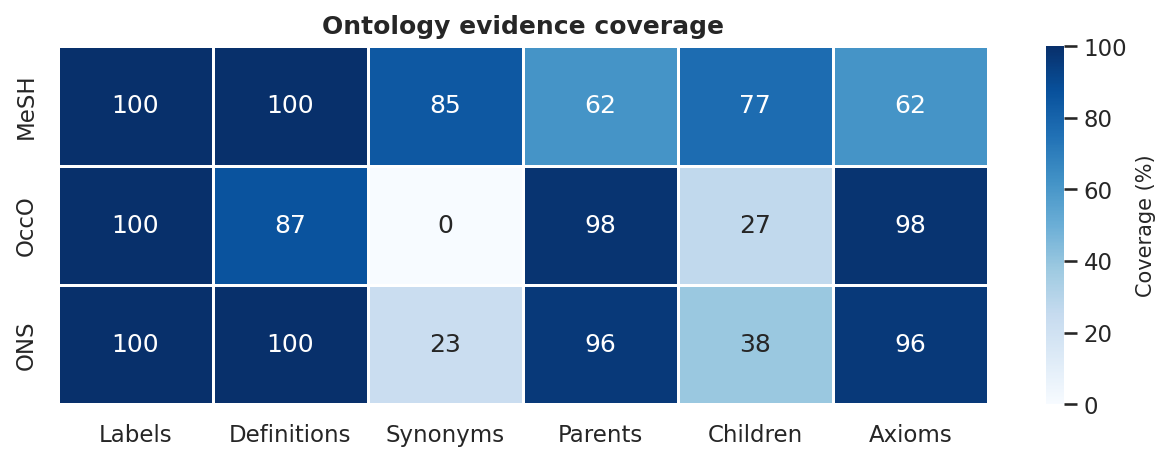

In [3]:
evidence = analysis["evidence_profile"].copy()
evidence_display = evidence.rename(columns={
    "ontology_label": "Ontology", "classes": "Classes",
    "label_coverage": "Labels", "definition_coverage": "Definitions",
    "synonym_coverage": "Synonyms", "parent_coverage": "Parents",
    "child_coverage": "Children", "axiom_coverage": "Asserted axioms",
    "duplicate_label_ambiguity": "Duplicate-label ambiguity",
})[["Ontology", "Classes", "Labels", "Definitions", "Synonyms", "Parents", "Children", "Asserted axioms", "Duplicate-label ambiguity"]]
display(show_table(
    evidence_display,
    percent_cols=["Labels", "Definitions", "Synonyms", "Parents", "Children", "Asserted axioms", "Duplicate-label ambiguity"],
    caption="Ontology-module evidence coverage",
))

heat = evidence.set_index("ontology_label")[[
    "label_coverage", "definition_coverage", "synonym_coverage",
    "parent_coverage", "child_coverage", "axiom_coverage",
]]
heat.columns = ["Labels", "Definitions", "Synonyms", "Parents", "Children", "Axioms"]
fig, ax = plt.subplots(figsize=(10, 3.1))
sns.heatmap(heat * 100, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "Coverage (%)"}, linewidths=.6, ax=ax)
ax.set_title("Ontology evidence coverage")
ax.set_xlabel("")
ax.set_ylabel("")
save_figure(fig, "01_ontology_evidence_coverage.png")


## 2. Ground-truth audit and pair-level normalisation

The three ODS sheets contain **grouped positive mappings**, alternative properties, free-text evidence, and partially missing agreement counts. They are not already a complete pair-level gold standard. The primary reference expands only explicitly named ontology classes after spelling/label normalisation and duplicate removal. A separate sensitivity set expands the OccO–ONS phrase “All food products” to the six explicitly represented ONS product classes.

The resulting pair sets support coverage and retention of known positives. They do not support unrestricted false-positive counts or exact free-text predicate grading.


In [4]:
gt = analysis["ground_truth_audit"].rename(columns={
    "ontology_pair_label": "Pair", "grouped_rows": "Grouped rows",
    "rows_with_reviewer_agreement": "Agreement present",
    "rows_missing_reviewer_agreement": "Agreement missing",
    "direction_label_anomalies": "Out-of-pair direction labels",
    "exact_pair_reference": "Exact pairs", "expanded_pair_reference": "Sensitivity pairs",
    "verified_negative_pairs": "Verified negatives",
})[["Pair", "Grouped rows", "Agreement present", "Agreement missing", "Out-of-pair direction labels", "Exact pairs", "Sensitivity pairs", "Verified negatives"]]
display(show_table(gt, caption="Audit of supplied grouped mapping sheets"))
display(callout(
    "Ground-truth boundary",
    "The primary analysis uses exact pair-level expansions (28 MeSH–ONS, 22 OccO–MeSH, 38 OccO–ONS). "
    "The OccO–ONS sensitivity expansion contains 58 pairs and is always labelled separately.",
    color=COLORS["semantic"],
))


Pair,Grouped rows,Agreement present,Agreement missing,Out-of-pair direction labels,Exact pairs,Sensitivity pairs,Verified negatives
MeSH–ONS,11,10,1,9,28,28,0
OccO–MeSH,5,5,0,0,22,22,0
OccO–ONS,5,3,2,0,38,58,0


HTMLBlock()

Pair,Group,Scope,Rule / note
MeSH–ONS,MO_04,exact,The ODS cell says MeSH→OccO inside the MeSH–ONS sheet; corrected to the participating ontologies.
MeSH–ONS,MO_06,exact,Food Labelling normalised to the ontology label Food Labeling.
MeSH–ONS,MO_11,exact,Public Heath normalised to Public Health.
OccO–ONS,OO_01,exact,Group caption excluded; four explicitly listed occupation classes retained.
OccO–ONS,OO_05,exact,food/beverages serving worker normalised to the ontology label.
OccO–ONS,OO_04,hierarchy_expanded,Sensitivity analysis: 'All food products' expanded to the six explicitly represented product classes.


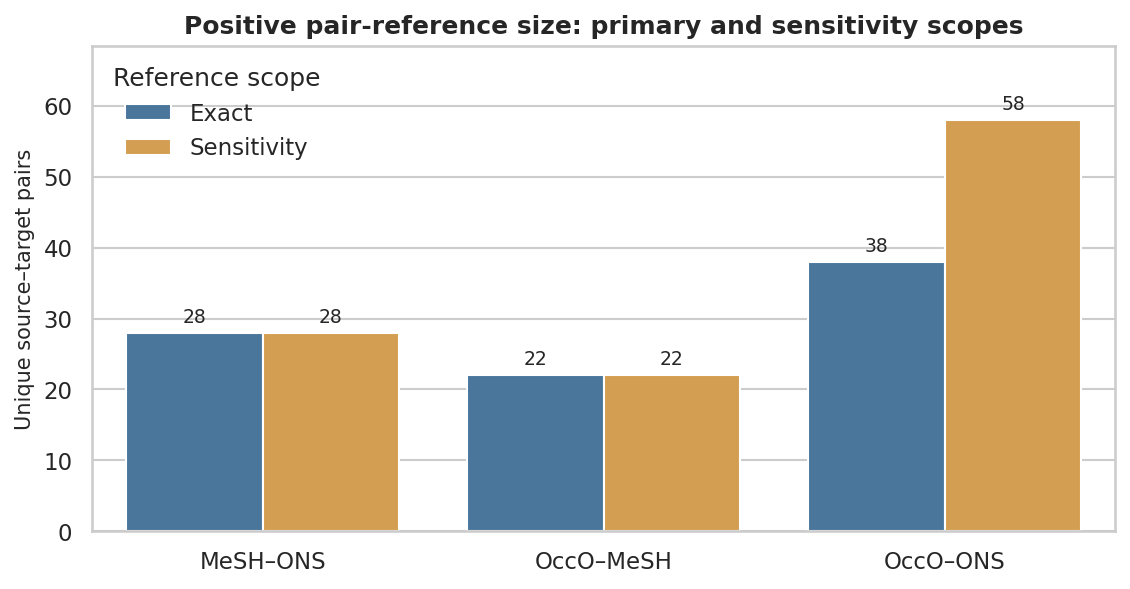

In [5]:
ref_counts = (
    analysis["ground_truth_audit"]
    [["ontology_pair_label", "exact_pair_reference", "expanded_pair_reference"]]
    .rename(columns={"ontology_pair_label": "Pair", "exact_pair_reference": "Exact", "expanded_pair_reference": "Sensitivity"})
)
ref_long = ref_counts.melt("Pair", var_name="Reference scope", value_name="Pairs")
fig, ax = plt.subplots(figsize=(8.8, 4.2))
sns.barplot(data=ref_long, x="Pair", y="Pairs", hue="Reference scope",
            palette=[COLORS["stage1"], COLORS["repair"]], ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
ax.set_title("Positive pair-reference size: primary and sensitivity scopes")
ax.set_xlabel("")
ax.set_ylabel("Unique source–target pairs")
ax.set_ylim(0, max(ref_long["Pairs"]) * 1.18)
save_figure(fig, "02_reference_pair_scope.png")

normalisation_notes = analysis["expanded_reference"].copy()
normalisation_notes["Pair"] = normalisation_notes["ontology_pair"].map(PAIR_LABELS)
normalisation_notes = (
    normalisation_notes
    .loc[normalisation_notes["normalisation_note"].astype(str).str.len().gt(0),
         ["Pair", "group_id", "reference_type", "normalisation_note"]]
    .drop_duplicates()
    .rename(columns={"group_id": "Group", "reference_type": "Scope", "normalisation_note": "Rule / note"})
)
display(show_table(normalisation_notes, caption="Explicit normalisation and expansion rules"))


## 3. Experimental run matrix and provenance

The intended Stage&nbsp;2 design contains 24 cells: three ontology pairs × two Stage&nbsp;1 selectors × two example conditions × two directions. The archive is unbalanced. Main analyses include only cells whose observed Stage&nbsp;2 pair set exactly matches the Stage&nbsp;1 set declared by the filename.


Run,Pair,S1 selector,Examples,Direction,Expected,Observed,Status,Reason
OM_L_E0_D12,OccO–MeSH,Llama,without,1-2,44,0,empty_run,The Stage 2 file is empty although Stage 1 retained candidates.
OM_L_E0_D21,OccO–MeSH,Llama,without,2-1,44,0,missing_file,No corresponding CSV file is present.
OM_L_E1_D12,OccO–MeSH,Llama,with,1-2,44,0,missing_file,No corresponding CSV file is present.
OM_L_E1_D21,OccO–MeSH,Llama,with,2-1,44,0,missing_file,No corresponding CSV file is present.
OO_L_E1_D21,OccO–ONS,Llama,with,2-1,122,34,candidate_provenance_mismatch,Observed pair set equals the Qwen Stage 1 candidate set exactly.


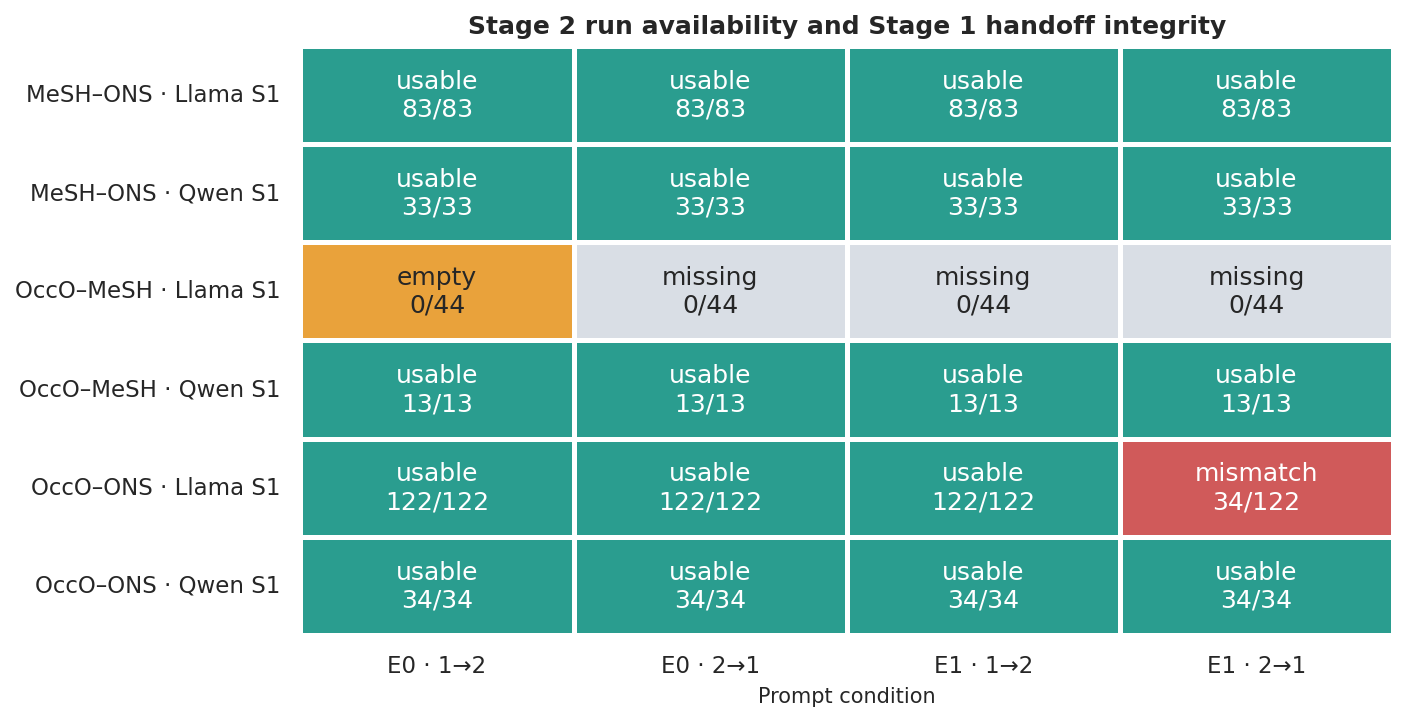

In [6]:
manifest = analysis["stage2_manifest"].copy()
manifest["row"] = manifest["ontology_pair_label"] + " · " + manifest["stage1_model"] + " S1"
manifest["condition"] = manifest["examples"].map({"without": "E0", "with": "E1"}) + " · " + manifest["direction"].map({"1-2": "1→2", "2-1": "2→1"})
row_order = [f"{PAIR_LABELS[p]} · {m} S1" for p in PAIR_ORDER for m in MODEL_ORDER]
col_order = ["E0 · 1→2", "E0 · 2→1", "E1 · 1→2", "E1 · 2→1"]
status_value = {"missing_file": 0, "empty_run": 1, "candidate_provenance_mismatch": 2, "complete": 3}
status_symbol = {"missing_file": "missing", "empty_run": "empty", "candidate_provenance_mismatch": "mismatch", "complete": "usable"}
matrix = manifest.pivot(index="row", columns="condition", values="status").reindex(index=row_order, columns=col_order)
values = matrix.replace(status_value).astype(float)
annotations = pd.DataFrame("", index=matrix.index, columns=matrix.columns)
for _, r in manifest.iterrows():
    annotations.loc[r["row"], r["condition"]] = (
        f"{status_symbol[r['status']]}\n{int(r['observed_rows'])}/{int(r['expected_candidates'])}"
    )
cmap = mcolors.ListedColormap(["#D9DEE5", "#E9A23B", "#D05A5A", "#2A9D8F"])
fig, ax = plt.subplots(figsize=(9.4, 5.1))
sns.heatmap(values, annot=annotations, fmt="", cmap=cmap, vmin=-.5, vmax=3.5,
            cbar=False, linewidths=1.5, linecolor="white", ax=ax)
ax.set_title("Stage 2 run availability and Stage 1 handoff integrity")
ax.set_xlabel("Prompt condition")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
save_figure(fig, "03_stage2_run_matrix.png")

issues = manifest.loc[~manifest["analysis_included"], [
    "run_id", "ontology_pair_label", "stage1_model", "examples", "direction",
    "expected_candidates", "observed_rows", "status", "provenance_note",
]].rename(columns={
    "run_id": "Run", "ontology_pair_label": "Pair", "stage1_model": "S1 selector",
    "examples": "Examples", "direction": "Direction", "expected_candidates": "Expected",
    "observed_rows": "Observed", "status": "Status", "provenance_note": "Reason",
})
display(show_table(issues, caption="Excluded or unavailable Stage 2 cells"))


## 4. RQ2a — Stage 1 candidate selection

This block addresses the Stage&nbsp;1 component of **RQ2**. Stage&nbsp;1 is evaluated against the ordered Cartesian product for each ontology pair. Candidate selection rate measures reduction, while positive-reference coverage measures whether explicitly supported pairs survive that reduction. Candidate-set overlap additionally shows whether Llama and Qwen merely differ in selectivity or expose substantively different search spaces to Stage&nbsp;2.

These measures should be read together: a smaller set is efficient only if it does not discard too much supported material. Because the reference is positive-only, higher retained coverage does not by itself establish higher global precision.


Pair,S1 selector,Pair universe,Candidates,Selection rate,Exact reference,Exact retained,Exact coverage,Sensitivity reference,Sensitivity retained,Sensitivity coverage
MeSH–ONS,Llama,338,83,24.6%,28,17,60.7%,28,17,60.7%
MeSH–ONS,Qwen,338,33,9.8%,28,4,14.3%,28,4,14.3%
OccO–MeSH,Llama,676,44,6.5%,22,15,68.2%,22,15,68.2%
OccO–MeSH,Qwen,676,13,1.9%,22,6,27.3%,22,6,27.3%
OccO–ONS,Llama,1352,122,9.0%,38,28,73.7%,58,42,72.4%
OccO–ONS,Qwen,1352,34,2.5%,38,7,18.4%,58,10,17.2%


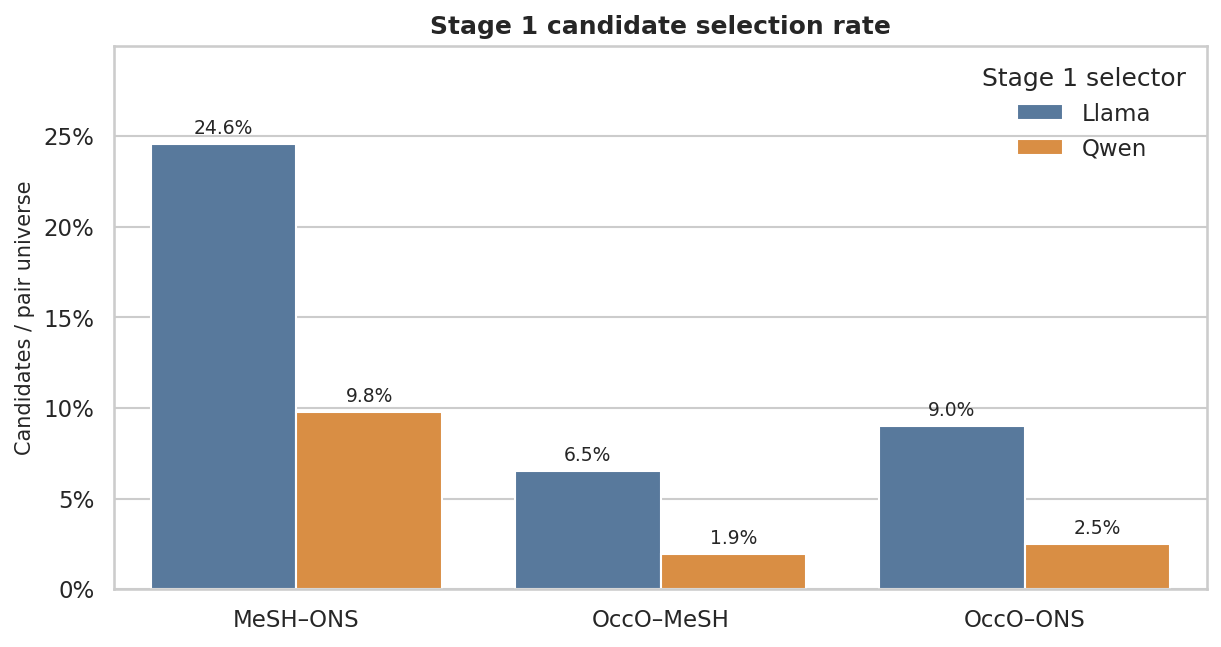

In [7]:
s1 = analysis["stage1_metrics"].sort_values(["ontology_pair", "stage1_model"]).copy()
s1_display = s1.rename(columns={
    "ontology_pair_label": "Pair", "stage1_model": "S1 selector",
    "pair_universe": "Pair universe", "candidate_pairs": "Candidates",
    "candidate_selection_rate": "Selection rate", "exact_reference_pairs": "Exact reference",
    "exact_reference_retained": "Exact retained", "exact_reference_coverage": "Exact coverage",
    "expanded_reference_pairs": "Sensitivity reference", "expanded_reference_retained": "Sensitivity retained",
    "expanded_reference_coverage": "Sensitivity coverage",
})[["Pair", "S1 selector", "Pair universe", "Candidates", "Selection rate", "Exact reference", "Exact retained", "Exact coverage", "Sensitivity reference", "Sensitivity retained", "Sensitivity coverage"]]
display(show_table(s1_display, percent_cols=["Selection rate", "Exact coverage", "Sensitivity coverage"], caption="Stage 1 candidate reduction and positive-reference retention"))

fig, ax = plt.subplots(figsize=(9.4, 4.7))
plot_data = s1.copy()
sns.barplot(data=plot_data, x="ontology_pair_label", y="candidate_selection_rate", hue="stage1_model",
            hue_order=MODEL_ORDER, palette=[COLORS["llama"], COLORS["qwen"]], ax=ax)
for container in ax.containers:
    labels = [f"{100 * bar.get_height():.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)
ax.set_title("Stage 1 candidate selection rate")
ax.set_xlabel("")
ax.set_ylabel("Candidates / pair universe")
ax.yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
ax.set_ylim(0, plot_data["candidate_selection_rate"].max() * 1.22)
ax.legend(title="Stage 1 selector")
save_figure(fig, "04_stage1_selection_rate.png")


Pair,Llama only,Shared,Qwen only,Union,Jaccard
MeSH–ONS,70,13,20,103,0.126
OccO–MeSH,32,12,1,45,0.267
OccO–ONS,100,22,12,134,0.164


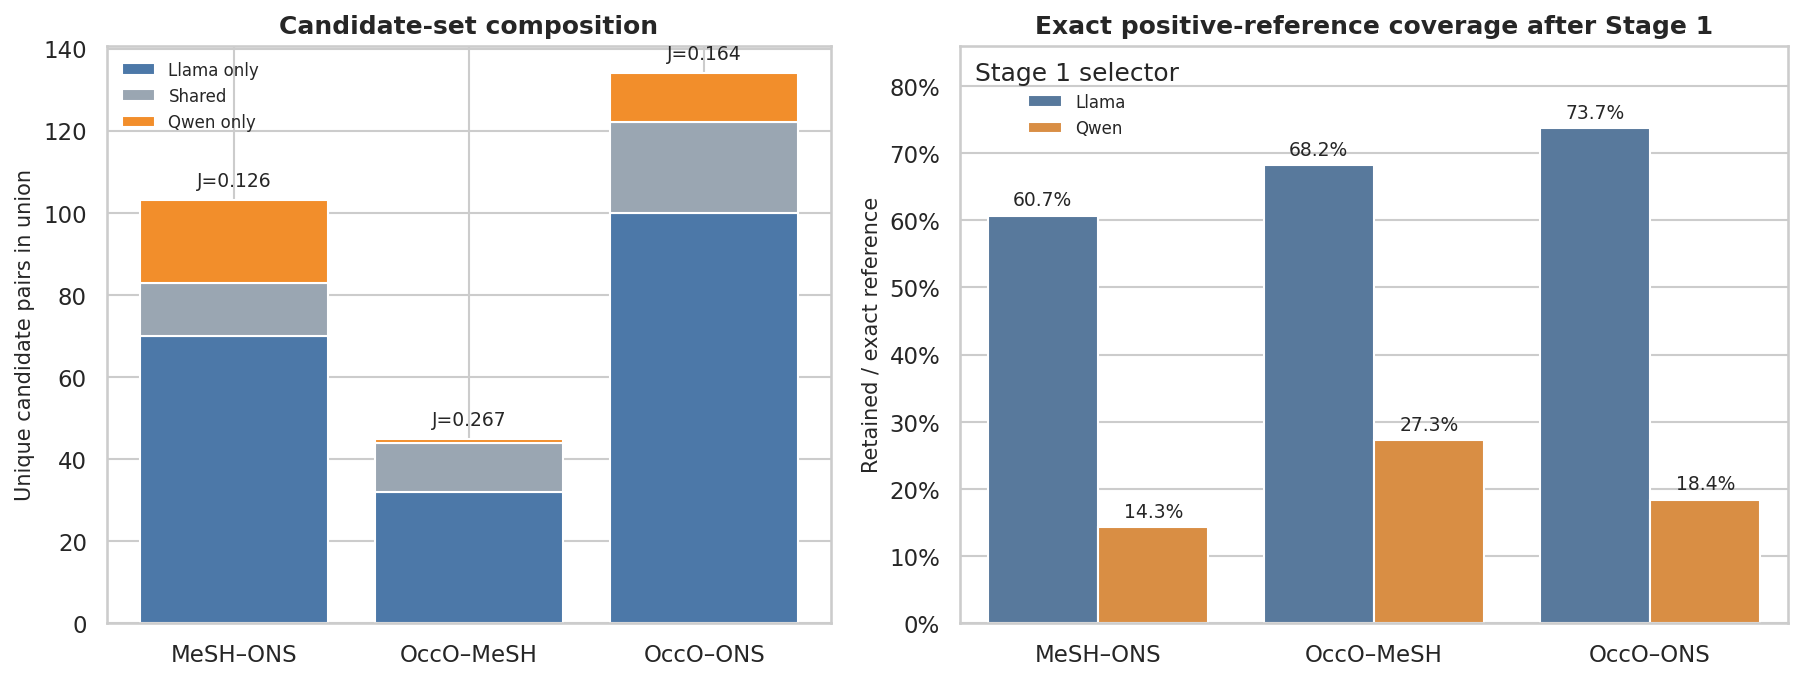

In [8]:
overlap = analysis["candidate_overlap"].copy()
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.7), gridspec_kw={"width_ratios": [1.05, 1.2]})

bottom = np.zeros(len(overlap))
overlap_colors = [COLORS["llama"], "#9AA6B2", COLORS["qwen"]]
for column, label, color in zip(["llama_only", "shared", "qwen_only"], ["Llama only", "Shared", "Qwen only"], overlap_colors):
    axes[0].bar(overlap["ontology_pair_label"], overlap[column], bottom=bottom, label=label, color=color)
    bottom += overlap[column].to_numpy()
for i, row in overlap.reset_index(drop=True).iterrows():
    axes[0].text(i, row["union"] + max(overlap["union"]) * .025, f"J={row['jaccard']:.3f}", ha="center", fontsize=9)
axes[0].set_title("Candidate-set composition")
axes[0].set_xlabel("")
axes[0].set_ylabel("Unique candidate pairs in union")
axes[0].legend(fontsize=8)

cov = s1[["ontology_pair_label", "stage1_model", "exact_reference_coverage"]]
sns.barplot(data=cov, x="ontology_pair_label", y="exact_reference_coverage", hue="stage1_model",
            hue_order=MODEL_ORDER, palette=[COLORS["llama"], COLORS["qwen"]], ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[f"{100*b.get_height():.1f}%" for b in container], padding=3, fontsize=9)
axes[1].set_title("Exact positive-reference coverage after Stage 1")
axes[1].set_xlabel("")
axes[1].set_ylabel("Retained / exact reference")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
axes[1].set_ylim(0, 0.86)
axes[1].legend(title="Stage 1 selector", fontsize=8)
fig.tight_layout()
save_figure(fig, "05_stage1_overlap_and_reference_coverage.png")

overlap_display = overlap.rename(columns={
    "ontology_pair_label": "Pair", "llama_only": "Llama only", "shared": "Shared",
    "qwen_only": "Qwen only", "union": "Union", "jaccard": "Jaccard",
})[["Pair", "Llama only", "Shared", "Qwen only", "Union", "Jaccard"]]
display(show_table(overlap_display, float_cols=["Jaccard"], caption="Stage 1 candidate-set overlap"))


## 5. RQ1a — Stage 1 → Stage 2 handoff integrity and pipeline profile

This block establishes the traceability prerequisite for **RQ1**. Before semantic retention can be interpreted, each usable Stage&nbsp;2 cell must contain exactly the candidate pair set declared by its Stage&nbsp;1 selector. Source/target IRIs and labels must also agree with the supplied OWL modules.

The resulting pipeline profile is descriptive: it shows how many pairs are available at successive stages, while the reference-fate analysis in RQ1b localises losses of expert-supported pairs more directly.


In [9]:
identity = analysis["identity_audit"].rename(columns={
    "stage": "Stage", "rows": "Rows", "source_iri_known_rate": "Source IRI known",
    "target_iri_known_rate": "Target IRI known", "source_label_match_rate": "Source label matches",
    "target_label_match_rate": "Target label matches",
})
display(show_table(identity, percent_cols=["Source IRI known", "Target IRI known", "Source label matches", "Target label matches"], caption="Concept identity and label consistency"))

manifest_summary = analysis["stage2_manifest"].groupby("status", as_index=False).agg(
    cells=("run_id", "size"), rows=("observed_rows", "sum")
).rename(columns={"status": "Status", "cells": "Cells", "rows": "Rows"})
display(show_table(manifest_summary, caption="Stage 2 archive status summary"))


Stage,Rows,Source IRI known,Target IRI known,Source label matches,Target label matches
Stage 1,329,100.0%,100.0%,100.0%,100.0%
Stage 2,1052,100.0%,100.0%,100.0%,100.0%


Status,Cells,Rows
candidate_provenance_mismatch,1,34
complete,19,1018
empty_run,1,0
missing_file,3,0


Pair,S1 selector,Universe,S1 candidates,Mean S2 usable,Mean S2 yes,Usable S2 runs
MeSH–ONS,Llama,338,83,83.000,77.750,4.0
MeSH–ONS,Qwen,338,33,33.000,29.750,4.0
OccO–MeSH,Llama,676,44,—,—,NaN
OccO–MeSH,Qwen,676,13,13.000,13.000,4.0
OccO–ONS,Llama,1352,122,121.667,106.000,3.0
OccO–ONS,Qwen,1352,34,34.000,29.000,4.0


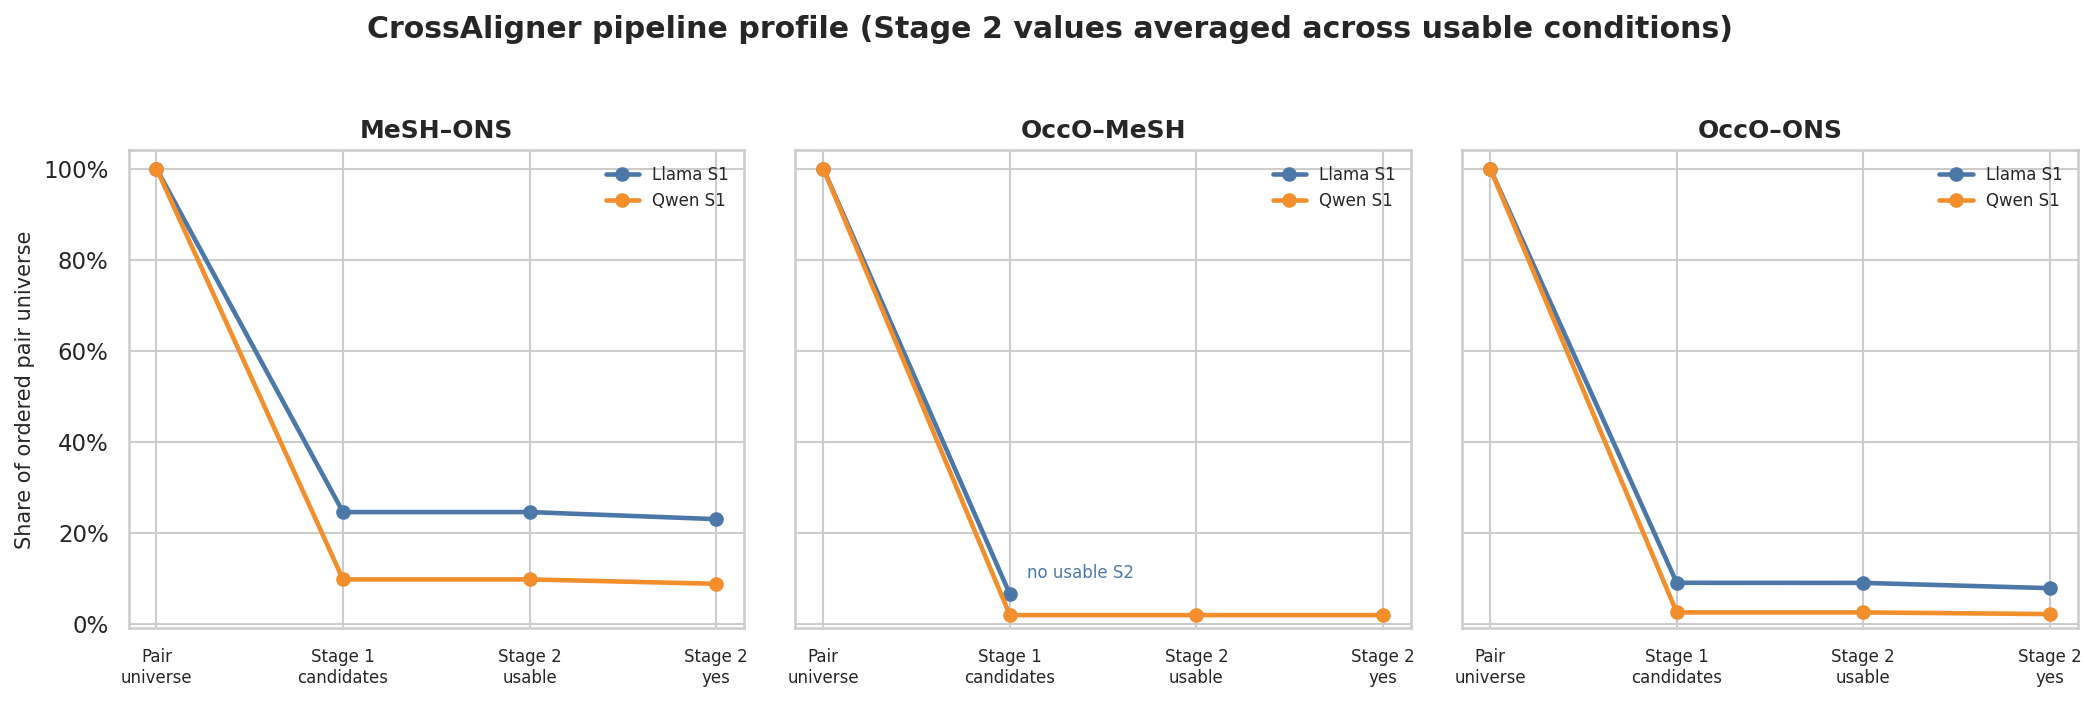

In [10]:
pipeline = s1[["ontology_pair", "ontology_pair_label", "stage1_model", "pair_universe", "candidate_pairs"]].copy()
s2_agg = analysis["stage2_metrics"].groupby(["ontology_pair", "stage1_model"], as_index=False).agg(
    stage2_usable_mean=("decision_usable_n", "mean"),
    stage2_yes_mean=("yes_n", "mean"),
    usable_runs=("run_id", "size"),
)
pipeline = pipeline.merge(s2_agg, on=["ontology_pair", "stage1_model"], how="left")

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.5), sharey=True)
stages = ["Pair\nuniverse", "Stage 1\ncandidates", "Stage 2\nusable", "Stage 2\nyes"]
for ax, pair in zip(axes, PAIR_ORDER):
    subset = pipeline[pipeline["ontology_pair"] == pair]
    for _, row in subset.iterrows():
        values = np.array([
            row["pair_universe"], row["candidate_pairs"],
            row["stage2_usable_mean"], row["stage2_yes_mean"],
        ], dtype=float) / row["pair_universe"] * 100
        color = COLORS["llama"] if row["stage1_model"] == "Llama" else COLORS["qwen"]
        ax.plot(stages, values, marker="o", linewidth=2.2, label=f"{row['stage1_model']} S1", color=color)
        if pd.isna(row["stage2_usable_mean"]):
            ax.annotate("no usable S2", (1, values[1]), xytext=(8, 8), textcoords="offset points", fontsize=8, color=color)
    ax.set_title(PAIR_LABELS[pair])
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylim(-1, 104)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Share of ordered pair universe")
fig.suptitle("CrossAligner pipeline profile (Stage 2 values averaged across usable conditions)", y=1.03, fontweight="bold")
fig.tight_layout()
save_figure(fig, "06_pipeline_profile.png")

pipeline_display = pipeline.rename(columns={
    "ontology_pair_label": "Pair", "stage1_model": "S1 selector", "pair_universe": "Universe",
    "candidate_pairs": "S1 candidates", "stage2_usable_mean": "Mean S2 usable",
    "stage2_yes_mean": "Mean S2 yes", "usable_runs": "Usable S2 runs",
})[["Pair", "S1 selector", "Universe", "S1 candidates", "Mean S2 usable", "Mean S2 yes", "Usable S2 runs"]]
display(show_table(pipeline_display, float_cols=["Mean S2 usable", "Mean S2 yes"], caption="Stage-wise row counts by pair and Stage 1 selector"))


## 6. RQ3a — Response contract and repair burden

This block addresses the technical-output component of **RQ3**. Four levels are kept separate:

- **Raw parseability:** the unmodified response is exactly one JSON object.
- **Decision recoverability:** all parseable objects agree on one `yes`/`no` decision.
- **Record recoverability:** the decision and relationship state resolve unambiguously.
- **Schema/state conformity:** the recovered record satisfies the two-field contract and the `yes`/`no` relationship-state rule.

Deterministic recovery removes no semantic ambiguity. Repeated objects with conflicting decisions remain unrecoverable; repeated positive objects with different relation sentences retain the decision but not a unique full record. These distinctions allow technical accessibility and contract conformity to be evaluated independently of semantic reference support.


Run,Pair,S1 selector,Examples,Direction,Raw JSON,Decision,Full record,Schema,State
MO_L_E1_D12,MeSH–ONS,Llama,with,1-2,95.2%,100.0%,100.0%,100.0%,100.0%
MO_L_E1_D21,MeSH–ONS,Llama,with,2-1,96.4%,100.0%,100.0%,100.0%,100.0%
MO_L_E0_D12,MeSH–ONS,Llama,without,1-2,100.0%,100.0%,100.0%,100.0%,100.0%
MO_L_E0_D21,MeSH–ONS,Llama,without,2-1,95.2%,100.0%,98.8%,98.8%,98.8%
MO_Q_E1_D12,MeSH–ONS,Qwen,with,1-2,87.9%,100.0%,100.0%,100.0%,100.0%
MO_Q_E1_D21,MeSH–ONS,Qwen,with,2-1,90.9%,100.0%,100.0%,100.0%,100.0%
MO_Q_E0_D12,MeSH–ONS,Qwen,without,1-2,60.6%,100.0%,90.9%,90.9%,90.9%
MO_Q_E0_D21,MeSH–ONS,Qwen,without,2-1,97.0%,100.0%,100.0%,100.0%,100.0%
OM_Q_E1_D12,OccO–MeSH,Qwen,with,1-2,84.6%,100.0%,92.3%,92.3%,92.3%
OM_Q_E1_D21,OccO–MeSH,Qwen,with,2-1,69.2%,100.0%,84.6%,84.6%,84.6%


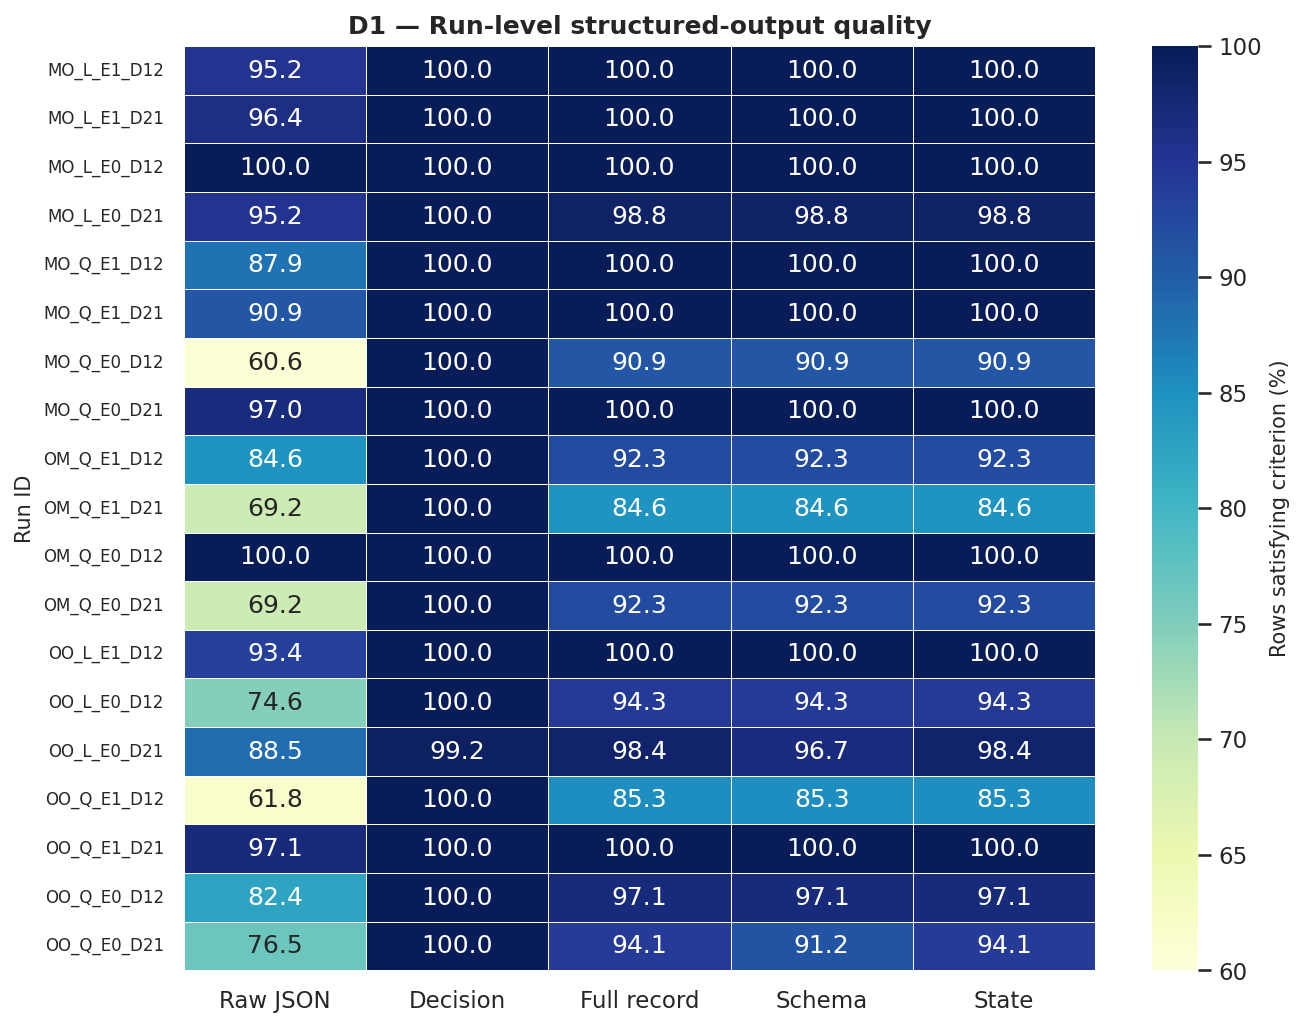

In [11]:
s2 = analysis["stage2_metrics"].sort_values(["ontology_pair", "stage1_model", "examples", "direction"]).copy()
d1_cols = ["raw_parseability", "decision_recoverability", "record_recoverability", "schema_conformity", "state_consistency"]
d1_labels = ["Raw JSON", "Decision", "Full record", "Schema", "State"]
d1_matrix = s2.set_index("run_id")[d1_cols]
d1_matrix.columns = d1_labels
fig, ax = plt.subplots(figsize=(9.8, 8.0))
sns.heatmap(d1_matrix * 100, annot=True, fmt=".1f", cmap="YlGnBu", vmin=60, vmax=100,
            cbar_kws={"label": "Rows satisfying criterion (%)"}, linewidths=.4, ax=ax)
ax.set_title("D1 — Run-level structured-output quality")
ax.set_xlabel("")
ax.set_ylabel("Run ID")
ax.tick_params(axis="y", rotation=0, labelsize=8)
save_figure(fig, "07_d1_contract_quality.png")

d1_display = s2[["run_id", "ontology_pair_label", "stage1_model", "examples", "direction"] + d1_cols].rename(columns={
    "run_id": "Run", "ontology_pair_label": "Pair", "stage1_model": "S1 selector", "examples": "Examples", "direction": "Direction",
    "raw_parseability": "Raw JSON", "decision_recoverability": "Decision", "record_recoverability": "Full record",
    "schema_conformity": "Schema", "state_consistency": "State",
})
display(show_table(d1_display, percent_cols=d1_labels, caption="D1 metric table"))


Defect,Affected rows,Rate
Extra text,123,12.1%
Code fence,79,7.8%
Repeated JSON,58,5.7%
Ambiguous relation,24,2.4%
Prompt echo,22,2.2%
Missing relation,6,0.6%
Extra keys,2,0.2%
Conflicting decision,1,0.1%
No JSON object,0,0.0%


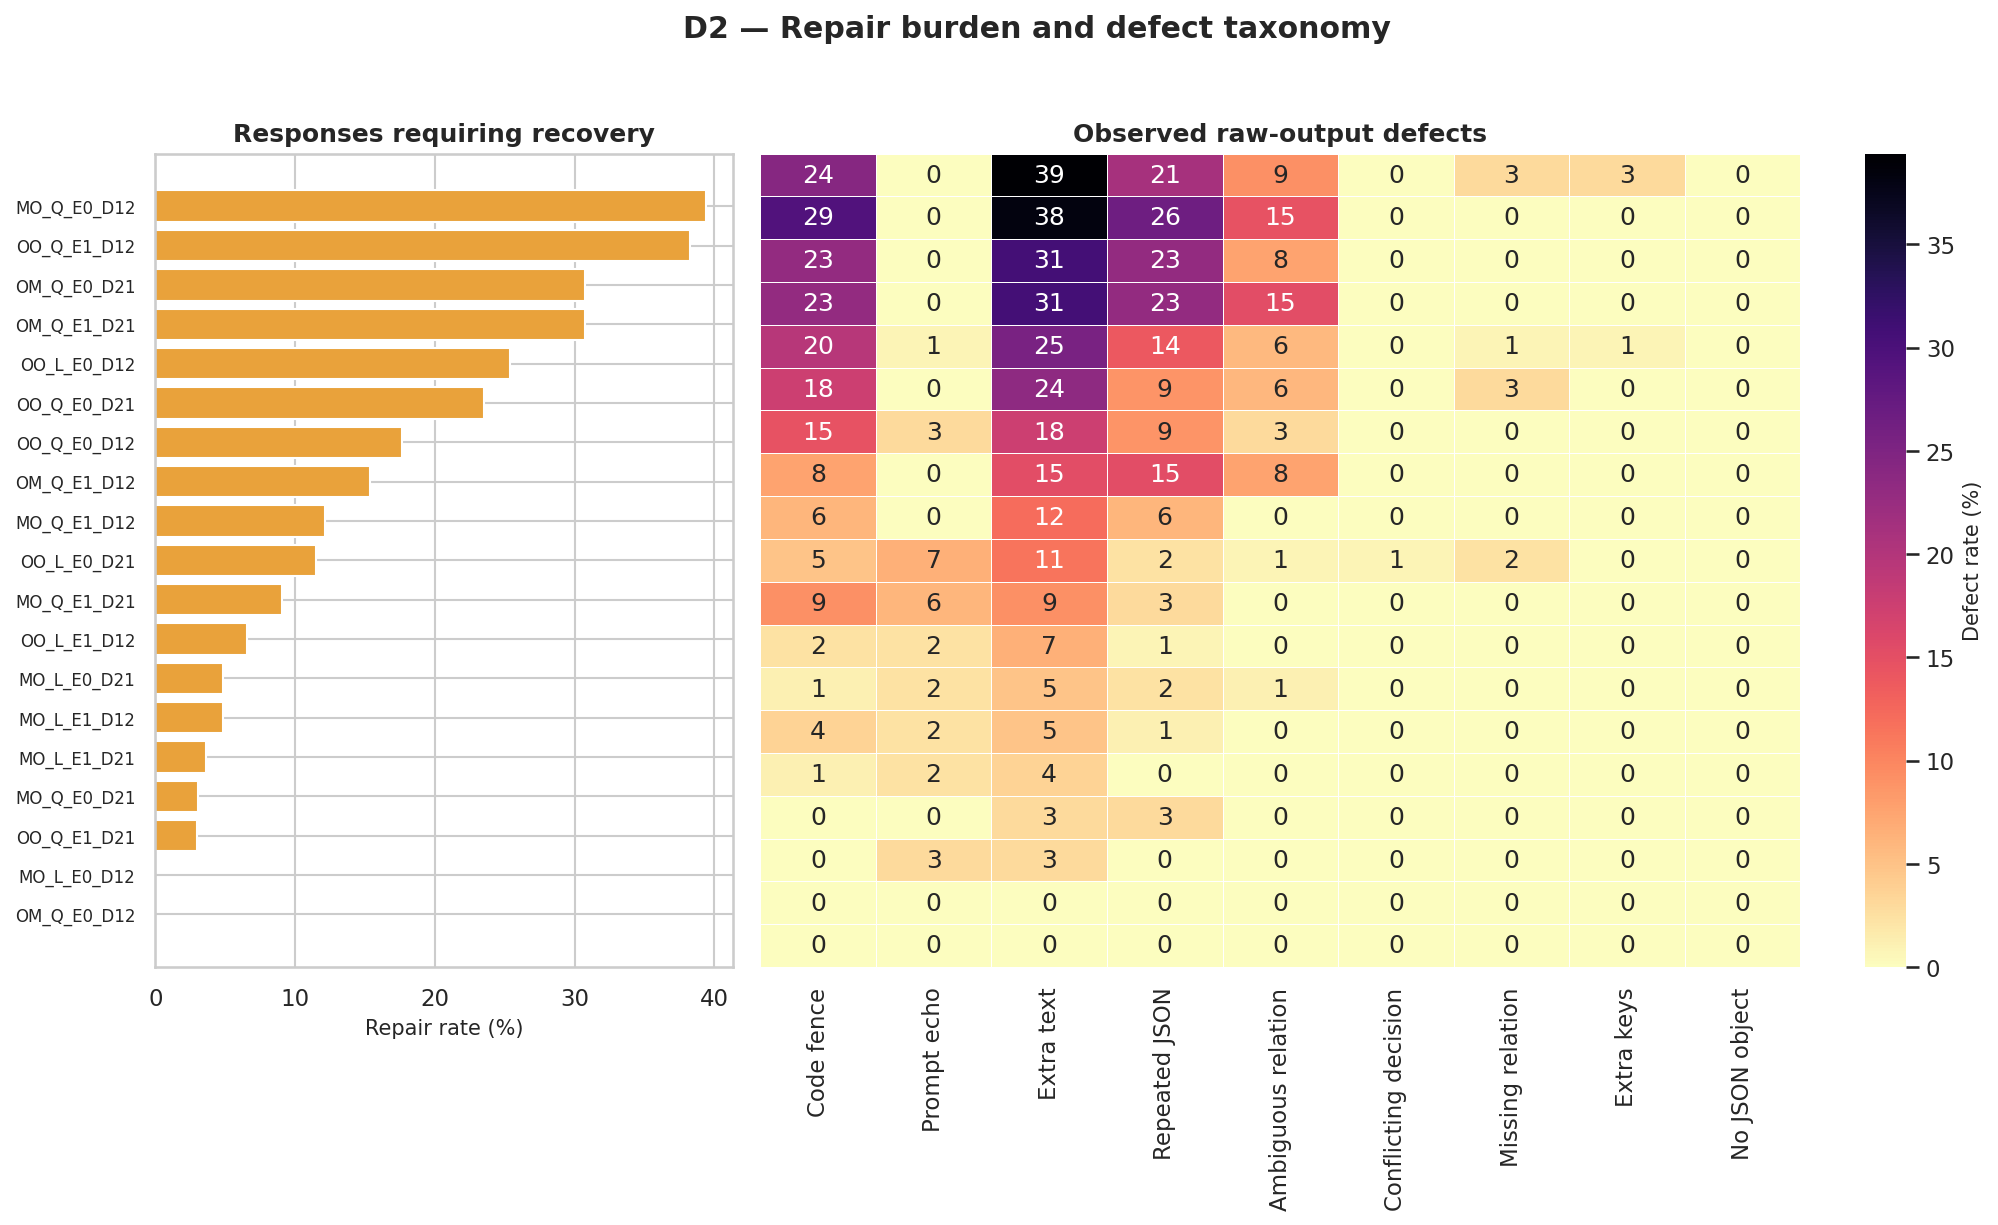

In [12]:
defect_names = [
    "code_fence", "prompt_echo", "extra_text", "repeated_json",
    "ambiguous_relationship", "conflicting_decision", "missing_relationship",
    "extra_keys", "no_parseable_object",
]
defect_labels = ["Code fence", "Prompt echo", "Extra text", "Repeated JSON", "Ambiguous relation", "Conflicting decision", "Missing relation", "Extra keys", "No JSON object"]
rate_cols = [f"defect_{name}_rate" for name in defect_names]
defect_matrix = s2.set_index("run_id")[rate_cols]
defect_matrix.columns = defect_labels
order = s2.sort_values("repair_rate", ascending=False)["run_id"]
defect_matrix = defect_matrix.reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 8.0), gridspec_kw={"width_ratios": [.8, 1.8]})
repair = s2.set_index("run_id").loc[order, "repair_rate"] * 100
axes[0].barh(repair.index, repair.values, color=COLORS["repair"])
axes[0].invert_yaxis()
axes[0].set_title("Responses requiring recovery")
axes[0].set_xlabel("Repair rate (%)")
axes[0].set_ylabel("")
axes[0].tick_params(axis="y", labelsize=8)
sns.heatmap(defect_matrix * 100, annot=True, fmt=".0f", cmap="magma_r", vmin=0,
            cbar_kws={"label": "Defect rate (%)"}, linewidths=.35, ax=axes[1])
axes[1].set_title("Observed raw-output defects")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelleft=False)
fig.suptitle("D2 — Repair burden and defect taxonomy", y=1.02, fontweight="bold")
fig.tight_layout()
save_figure(fig, "08_d2_repair_and_defects.png")

raw = analysis["stage2_rows"]
usable_raw = raw[raw["analysis_included"]]
defect_totals = pd.DataFrame({
    "Defect": defect_labels,
    "Affected rows": [int(usable_raw[name].sum()) for name in defect_names],
    "Rate": [usable_raw[name].mean() for name in defect_names],
}).sort_values("Affected rows", ascending=False)
display(show_table(defect_totals, percent_cols=["Rate"], caption="Defect totals across the 19 usable Stage 2 cells"))


## 7. RQ1b — Positive-reference support and loss localisation

This block provides the main semantic retention analysis for **RQ1**. For a positive pair-reference set \(R^+\), Stage&nbsp;1 coverage is

\[
C_{\mathrm{ref}}^{S1}=\frac{|C_r\cap R^+|}{|R^+|}.
\]

Conditional Stage&nbsp;2 retention measures how many supported pairs that reached Stage&nbsp;2 remain positive, while end-to-end support retains the full reference denominator:

\[
R_{\mathrm{ref}}^{S2}=\frac{|P_r^+\cap R^+|}{|C_r\cap R^+|}, \qquad
C_{\mathrm{ref}}^{E2E}=\frac{|P_r^+\cap R^+|}{|R^+|}.
\]

Under a complete handoff, \(C_{\mathrm{ref}}^{E2E}=C_{\mathrm{ref}}^{S1}R_{\mathrm{ref}}^{S2}\). This decomposition identifies the stage at which support is lost. A positive Stage&nbsp;2 decision is treated as support for the expert pair, not as proof that the generated free-text predicate exactly matches a unique gold relation.


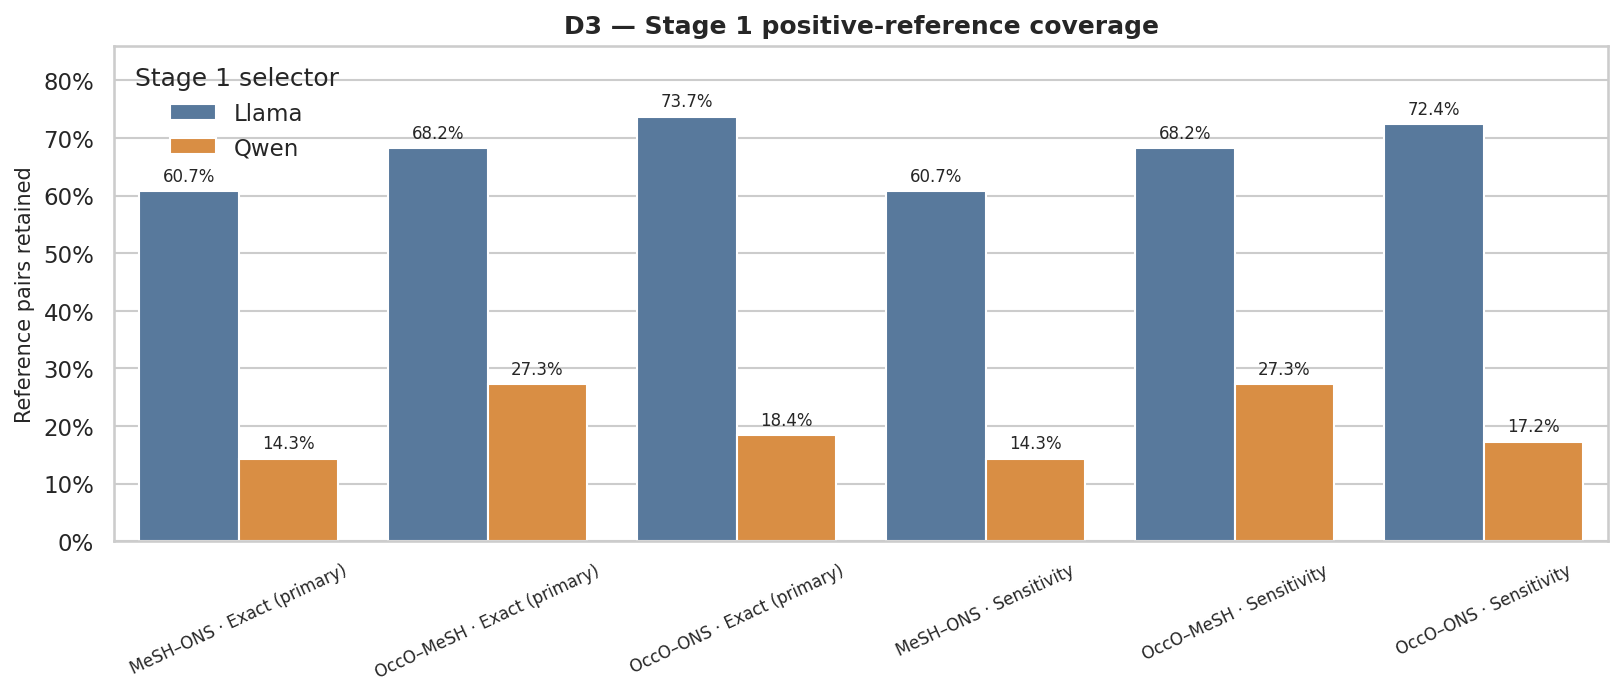

In [13]:
coverage_long = s1.melt(
    id_vars=["ontology_pair_label", "stage1_model"],
    value_vars=["exact_reference_coverage", "expanded_reference_coverage"],
    var_name="Scope", value_name="Coverage",
)
coverage_long["Scope"] = coverage_long["Scope"].map({
    "exact_reference_coverage": "Exact (primary)",
    "expanded_reference_coverage": "Sensitivity",
})
coverage_long["Panel"] = coverage_long["ontology_pair_label"] + " · " + coverage_long["Scope"]
fig, ax = plt.subplots(figsize=(11.0, 4.8))
sns.barplot(data=coverage_long, x="Panel", y="Coverage", hue="stage1_model", hue_order=MODEL_ORDER,
            palette=[COLORS["llama"], COLORS["qwen"]], ax=ax)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{100*b.get_height():.1f}%" for b in container], padding=3, fontsize=8)
ax.set_title("D3 — Stage 1 positive-reference coverage")
ax.set_xlabel("")
ax.set_ylabel("Reference pairs retained")
ax.yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
ax.set_ylim(0, .86)
ax.tick_params(axis="x", rotation=25, labelsize=8)
ax.legend(title="Stage 1 selector")
fig.tight_layout()
save_figure(fig, "09_d3_stage1_reference_coverage.png")


Run,Pair,S1 selector,Examples,Direction,Exact in S1,Exact S2 yes,Conditional S2 retention,End-to-end support
MO_L_E1_D12,MeSH–ONS,Llama,with,1-2,17,17,100.0%,60.7%
MO_L_E1_D21,MeSH–ONS,Llama,with,2-1,17,17,100.0%,60.7%
MO_L_E0_D12,MeSH–ONS,Llama,without,1-2,17,17,100.0%,60.7%
MO_L_E0_D21,MeSH–ONS,Llama,without,2-1,17,17,100.0%,60.7%
MO_Q_E1_D12,MeSH–ONS,Qwen,with,1-2,4,4,100.0%,14.3%
MO_Q_E1_D21,MeSH–ONS,Qwen,with,2-1,4,4,100.0%,14.3%
MO_Q_E0_D12,MeSH–ONS,Qwen,without,1-2,4,4,100.0%,14.3%
MO_Q_E0_D21,MeSH–ONS,Qwen,without,2-1,4,4,100.0%,14.3%
OM_Q_E1_D12,OccO–MeSH,Qwen,with,1-2,6,6,100.0%,27.3%
OM_Q_E1_D21,OccO–MeSH,Qwen,with,2-1,6,6,100.0%,27.3%


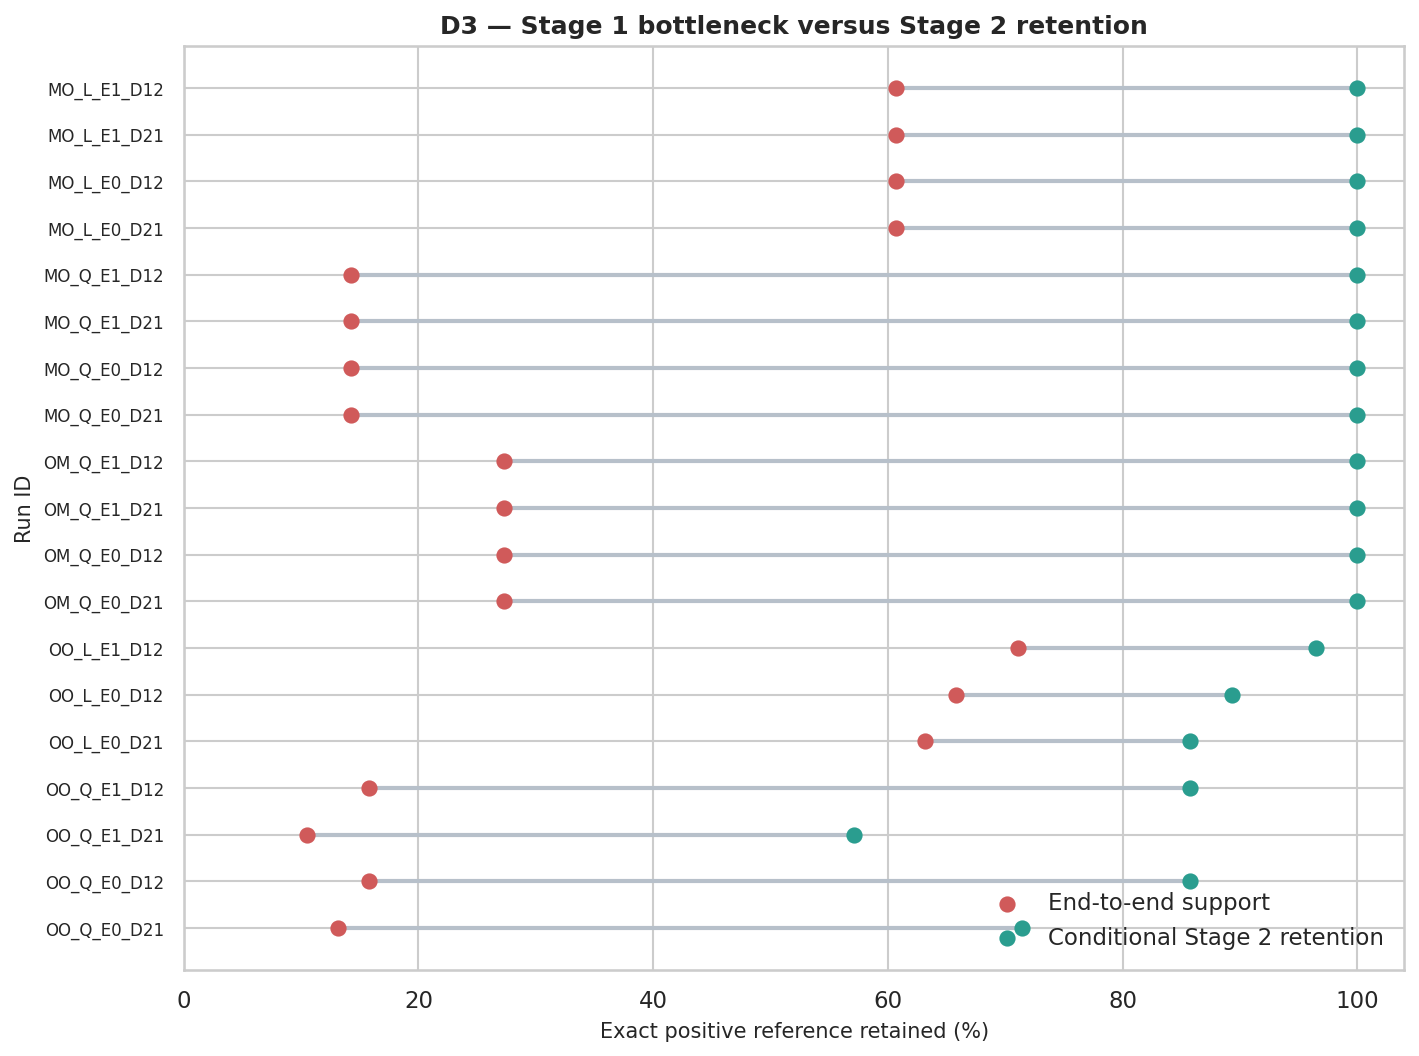

In [14]:
d3 = s2[[
    "run_id", "ontology_pair_label", "stage1_model", "examples", "direction",
    "exact_reference_in_stage1", "exact_reference_yes",
    "exact_stage2_conditional_retention", "exact_end_to_end_reference_support",
]].copy()
d3 = d3.sort_values(["ontology_pair_label", "stage1_model", "examples", "direction"])

fig, ax = plt.subplots(figsize=(10.5, 8.0))
y = np.arange(len(d3))
e2e = d3["exact_end_to_end_reference_support"].to_numpy() * 100
conditional = d3["exact_stage2_conditional_retention"].to_numpy() * 100
ax.hlines(y, e2e, conditional, color="#B7C0CA", linewidth=2)
ax.scatter(e2e, y, s=46, color=COLORS["semantic"], label="End-to-end support", zorder=3)
ax.scatter(conditional, y, s=46, color=COLORS["structural"], label="Conditional Stage 2 retention", zorder=3)
ax.set_yticks(y, d3["run_id"])
ax.invert_yaxis()
ax.set_xlim(0, 104)
ax.set_xlabel("Exact positive reference retained (%)")
ax.set_ylabel("Run ID")
ax.set_title("D3 — Stage 1 bottleneck versus Stage 2 retention")
ax.legend(loc="lower right")
ax.tick_params(axis="y", labelsize=8)
save_figure(fig, "10_d3_conditional_vs_end_to_end.png")

d3_display = d3.rename(columns={
    "run_id": "Run", "ontology_pair_label": "Pair", "stage1_model": "S1 selector", "examples": "Examples",
    "direction": "Direction", "exact_reference_in_stage1": "Exact in S1", "exact_reference_yes": "Exact S2 yes",
    "exact_stage2_conditional_retention": "Conditional S2 retention",
    "exact_end_to_end_reference_support": "End-to-end support",
})
display(show_table(d3_display, percent_cols=["Conditional S2 retention", "End-to-end support"], caption="Exact positive-reference support by usable Stage 2 cell"))


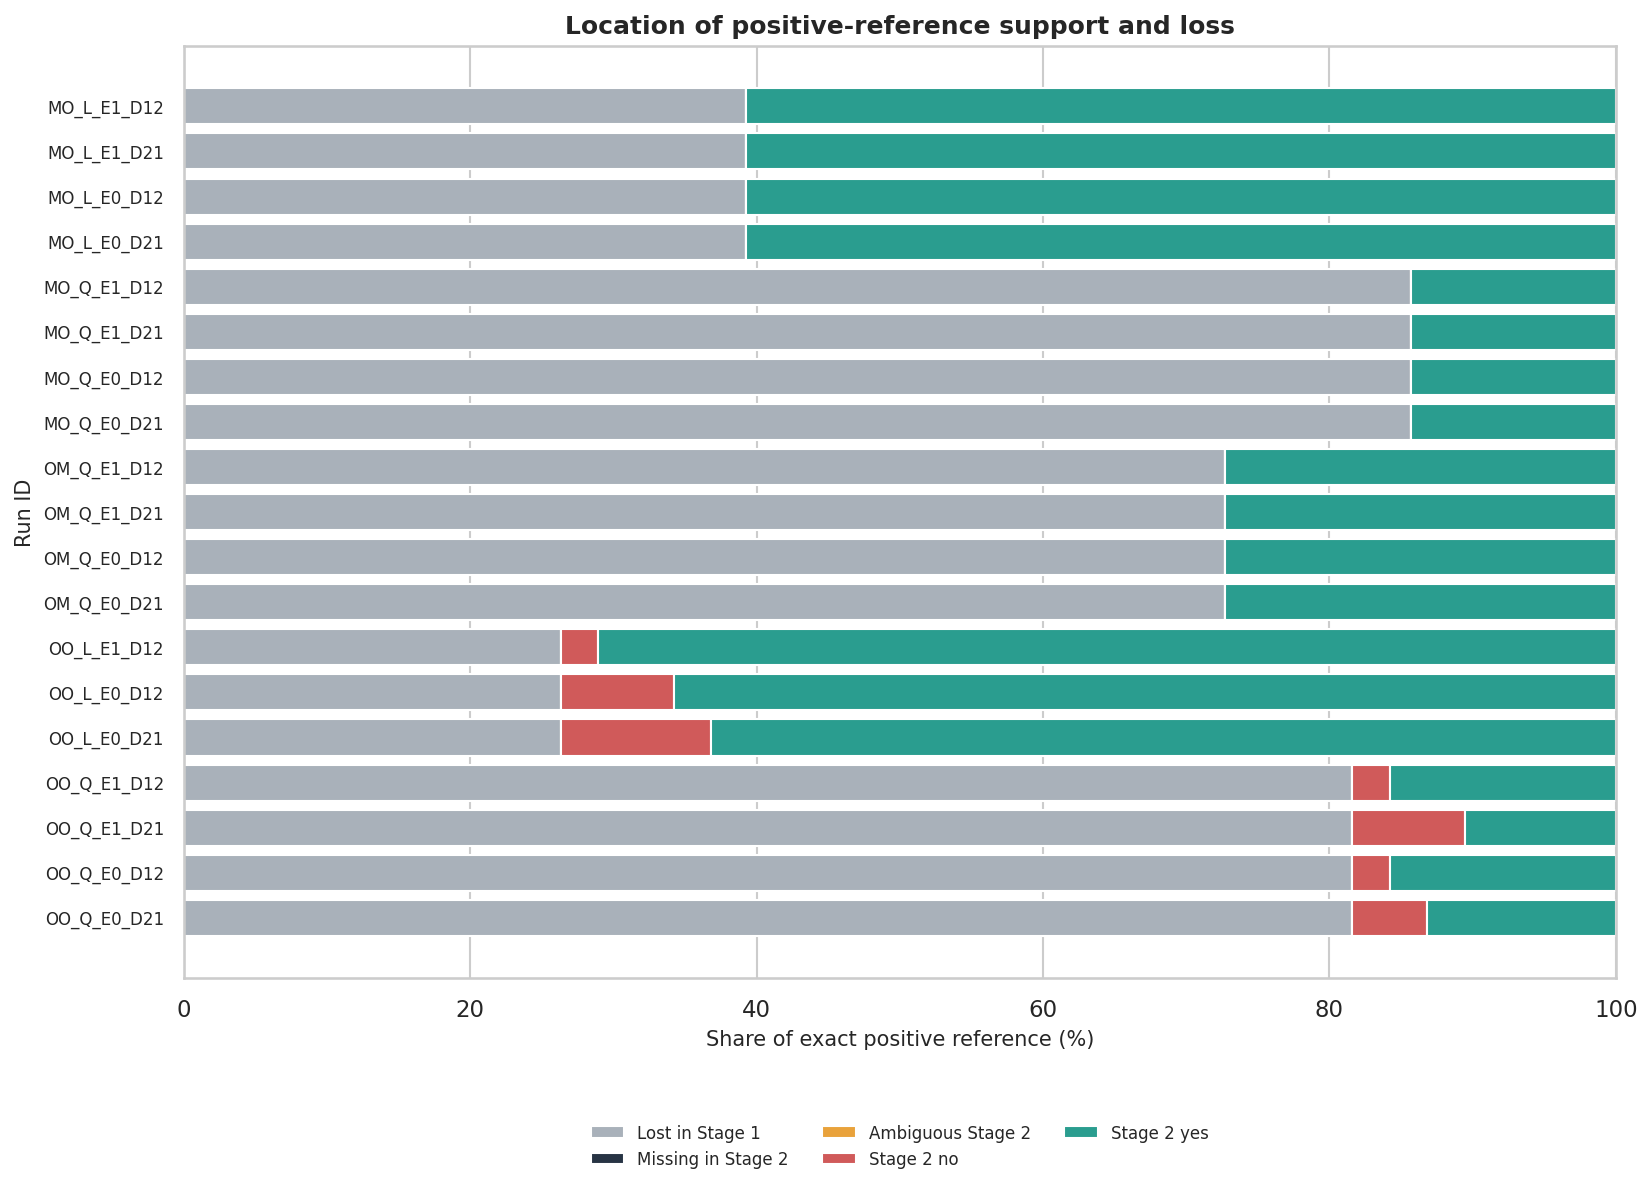

In [15]:
fate_order = ["lost_in_stage1", "missing_in_stage2", "ambiguous_stage2", "stage2_no", "stage2_yes"]
fate_labels = {
    "lost_in_stage1": "Lost in Stage 1", "missing_in_stage2": "Missing in Stage 2",
    "ambiguous_stage2": "Ambiguous Stage 2", "stage2_no": "Stage 2 no", "stage2_yes": "Stage 2 yes",
}
fate_colors = {
    "lost_in_stage1": "#A9B1BA", "missing_in_stage2": "#273444",
    "ambiguous_stage2": "#E9A23B", "stage2_no": "#D05A5A", "stage2_yes": "#2A9D8F",
}
fates = analysis["exact_fates"].groupby(["run_id", "fate"]).size().unstack(fill_value=0)
fates = fates.reindex(index=d3["run_id"], columns=fate_order, fill_value=0)
fates_pct = fates.div(fates.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11.2, 8.1))
left = np.zeros(len(fates_pct))
for fate in fate_order:
    ax.barh(fates_pct.index, fates_pct[fate], left=left, color=fate_colors[fate], label=fate_labels[fate])
    left += fates_pct[fate].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of exact positive reference (%)")
ax.set_ylabel("Run ID")
ax.set_title("Location of positive-reference support and loss")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(.5, -0.22), fontsize=8)
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
save_figure(fig, "11_reference_fates.png")


## 8. RQ2b — Stage 2 direction and example robustness

This block addresses the Stage&nbsp;2 configuration component of **RQ2**. Binary decision robustness is measured only on pair keys observed in both usable cells. Exact agreement is accompanied by Cohen’s \(\kappa\), because high agreement can arise from predominantly positive marginals. An undefined \(\kappa\) is retained as missing when both compared runs are constant; it is not replaced by 1.

Direction comparisons test sensitivity to reversing the requested source–target orientation, while example comparisons test sensitivity to example-guided prompting. “Stage&nbsp;1 selector” comparisons use only the intersection of two different candidate sets and therefore describe downstream behaviour on shared pairs, not an end-to-end model ranking.

The automatic comparison concerns the binary `related` decision. Free-text relation direction remains a separate manual-adjudication problem when paraphrases or passive constructions prevent reliable automatic classification.


Type,Run A,Run B,Pair,Comparable pairs,Agreement,Change rate,Cohen κ,yes→yes,yes→no,no→yes,no→no
Direction,MO_L_E1_D12,MO_L_E1_D21,MeSH–ONS,83,88.0%,12.0%,-0.064,73,5,5,0
Direction,MO_L_E0_D12,MO_L_E0_D21,MeSH–ONS,83,94.0%,6.0%,0.516,75,4,1,3
Direction,MO_Q_E1_D12,MO_Q_E1_D21,MeSH–ONS,33,87.9%,12.1%,0.275,28,1,3,1
Direction,MO_Q_E0_D12,MO_Q_E0_D21,MeSH–ONS,33,84.8%,15.2%,0.218,27,1,4,1
Direction,OM_Q_E1_D12,OM_Q_E1_D21,OccO–MeSH,13,100.0%,0.0%,—,13,0,0,0
Direction,OM_Q_E0_D12,OM_Q_E0_D21,OccO–MeSH,13,100.0%,0.0%,—,13,0,0,0
Direction,OO_L_E0_D12,OO_L_E0_D21,OccO–ONS,121,86.0%,14.0%,0.408,96,12,5,8
Direction,OO_Q_E1_D12,OO_Q_E1_D21,OccO–ONS,34,88.2%,11.8%,0.544,27,4,0,3
Direction,OO_Q_E0_D12,OO_Q_E0_D21,OccO–ONS,34,88.2%,11.8%,0.534,27,3,1,3
Examples,MO_L_E0_D12,MO_L_E1_D12,MeSH–ONS,83,91.6%,8.4%,0.178,75,4,3,1


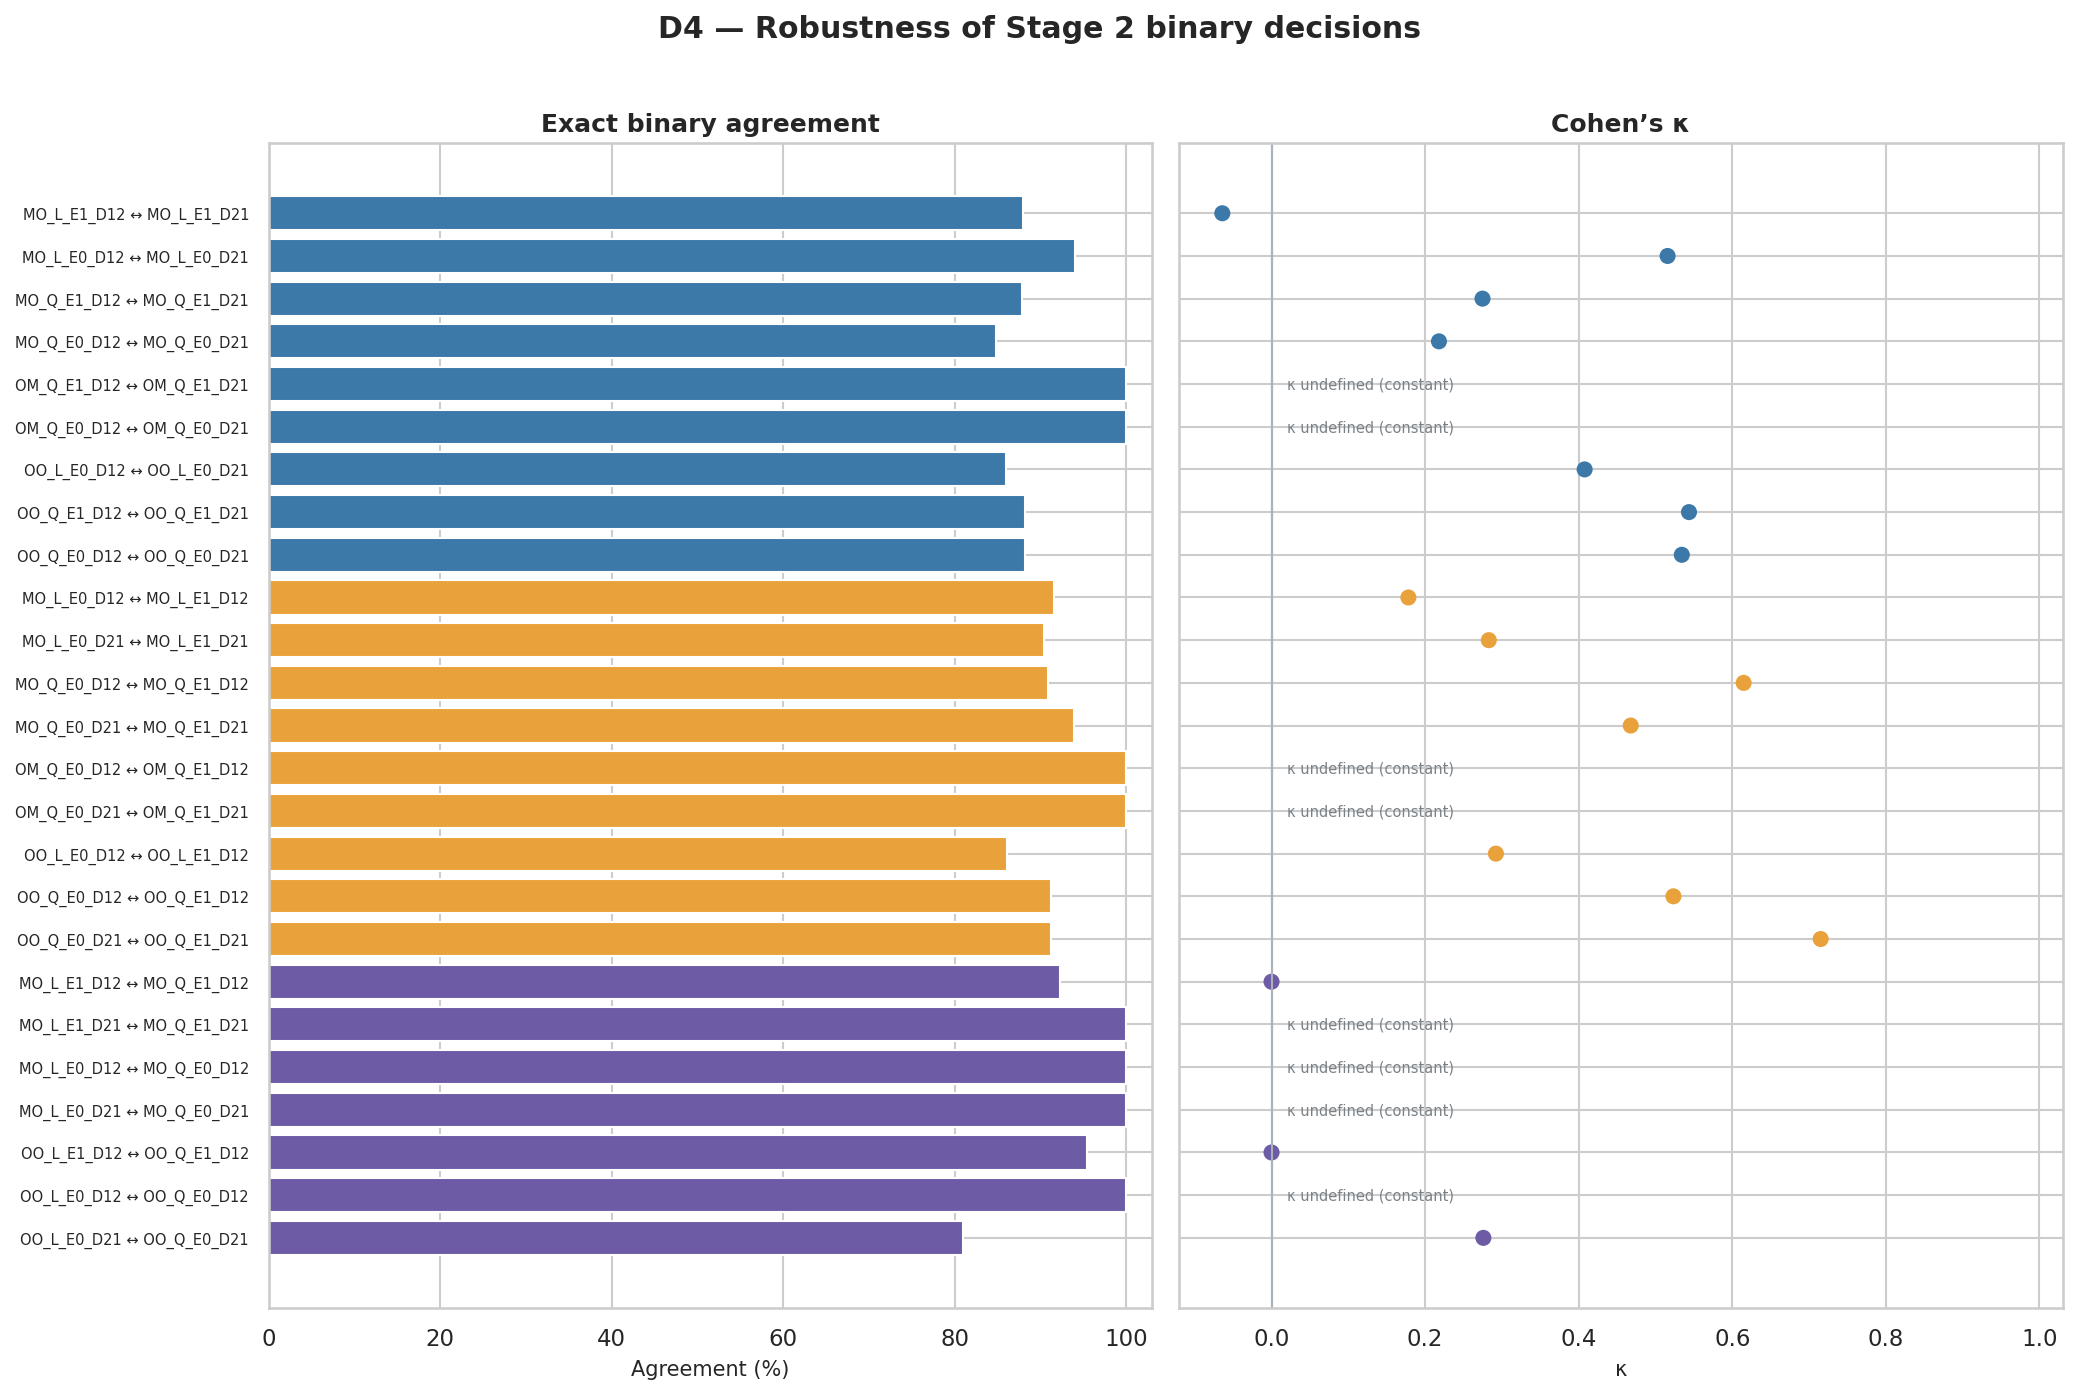

In [16]:
comparisons = analysis["comparisons"].copy()
comparison_labels = {"direction": "Direction", "examples": "Examples", "stage1_selector": "S1 selector (overlap only)"}
comparisons["Type"] = comparisons["comparison_type"].map(comparison_labels)
comparisons["Label"] = comparisons["run_a"] + " ↔ " + comparisons["run_b"]
plot_comp = comparisons.sort_values(["comparison_type", "ontology_pair", "stage1_model", "contrast"])

fig, axes = plt.subplots(1, 2, figsize=(14.0, 9.2), sharey=True)
y = np.arange(len(plot_comp))
colors = plot_comp["comparison_type"].map({"direction": COLORS["stage1"], "examples": COLORS["repair"], "stage1_selector": COLORS["robustness"]})
axes[0].barh(y, plot_comp["agreement"] * 100, color=colors)
axes[0].set_title("Exact binary agreement")
axes[0].set_xlabel("Agreement (%)")
axes[0].set_yticks(y, plot_comp["Label"])
axes[0].invert_yaxis()
axes[0].set_xlim(0, 103)
axes[0].tick_params(axis="y", labelsize=7)

axes[1].axvline(0, color="#A9B1BA", linewidth=1)
valid_kappa = plot_comp["cohen_kappa"].notna()
axes[1].scatter(plot_comp.loc[valid_kappa, "cohen_kappa"], y[valid_kappa], c=colors[valid_kappa], s=45)
for yi in y[~valid_kappa]:
    axes[1].text(0.02, yi, "κ undefined (constant)", va="center", fontsize=7, color=COLORS["neutral"])
axes[1].set_title("Cohen’s κ")
axes[1].set_xlabel("κ")
axes[1].set_xlim(-.12, 1.03)
axes[1].tick_params(axis="y", left=False, labelleft=False)
fig.suptitle("D4 — Robustness of Stage 2 binary decisions", y=1.01, fontweight="bold")
fig.tight_layout()
save_figure(fig, "12_d4_robustness.png")

comp_display = plot_comp[[
    "Type", "run_a", "run_b", "ontology_pair_label", "comparable_pairs", "agreement",
    "decision_change_rate", "cohen_kappa", "yes_yes", "yes_no", "no_yes", "no_no",
]].rename(columns={
    "run_a": "Run A", "run_b": "Run B", "ontology_pair_label": "Pair", "comparable_pairs": "Comparable pairs",
    "agreement": "Agreement", "decision_change_rate": "Change rate", "cohen_kappa": "Cohen κ",
    "yes_yes": "yes→yes", "yes_no": "yes→no", "no_yes": "no→yes", "no_no": "no→no",
})
display(show_table(comp_display, percent_cols=["Agreement", "Change rate"], float_cols=["Cohen κ"], caption="Paired robustness comparisons"))


Surface-order triage,Review priority,Positive relationships
expected_object_before_subject,priority_review,327
expected_subject_before_object,standard_review,476
one_or_both_labels_not_literal,priority_review,113


HTMLBlock()

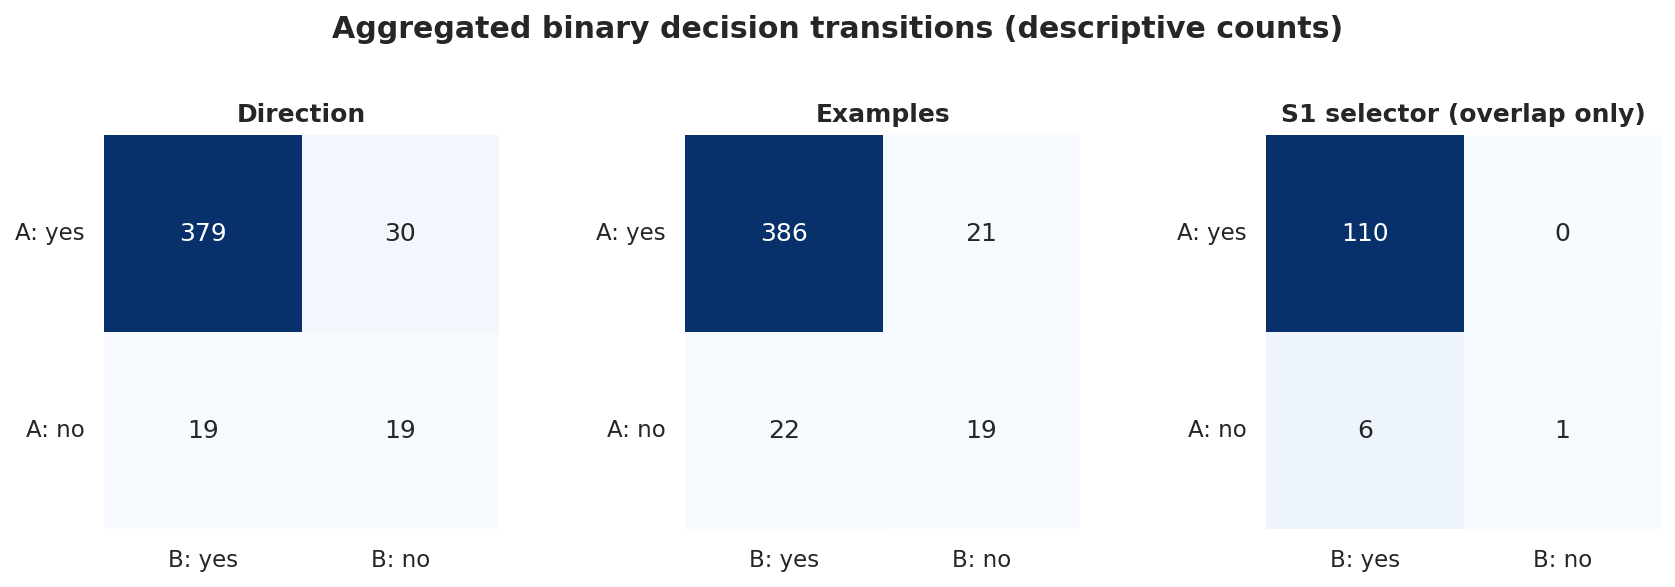

In [17]:
transition = comparisons.groupby("comparison_type")[["yes_yes", "yes_no", "no_yes", "no_no"]].sum()
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.7))
for ax, kind in zip(axes, ["direction", "examples", "stage1_selector"]):
    row = transition.loc[kind]
    matrix = np.array([[row["yes_yes"], row["yes_no"]], [row["no_yes"], row["no_no"]]])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=["B: yes", "B: no"], yticklabels=["A: yes", "A: no"], ax=ax)
    ax.set_title(comparison_labels[kind])
    ax.tick_params(axis="y", rotation=0)
fig.suptitle("Aggregated binary decision transitions (descriptive counts)", y=1.03, fontweight="bold")
fig.tight_layout()
save_figure(fig, "13_d4_transition_matrices.png")

direction_queue = analysis["direction_review_queue"]
direction_summary = direction_queue.groupby(["surface_triage", "review_priority"], as_index=False).size().rename(columns={
    "surface_triage": "Surface-order triage", "review_priority": "Review priority", "size": "Positive relationships",
})
display(show_table(direction_summary, caption="Manual relation-direction review queue"))
display(callout(
    "No automatic direction-conformity score",
    "Surface order is used only to prioritise the exported review queue. Passive constructions, omitted labels, and paraphrases require manual adjudication before a defensible C_dir value can be reported.",
    color=COLORS["robustness"],
))


## 9. RQ3b — Multidimensional diagnostic profile

This block synthesises the quality measures for **RQ3**. The final profile intentionally contains **no composite score**. Each metric answers a different question, has a different denominator, and can move independently.

The diagnostic table reports applicability, empirical range, interquartile range, and number of observed values so that near-ceiling metrics and more strongly discriminating metrics remain visible. Different empirical ranges are interpreted as different sensitivity to observed run variation, not as proof of statistical independence or non-redundancy.


Metric,Applicable runs,Minimum,Maximum,Range,IQR,Unique values
Run coverage,19,100.0%,100.0%,0.0%,0.0%,1
Raw parseability,19,60.6%,100.0%,39.4%,20.3%,16
Decision recoverability,19,99.2%,100.0%,0.8%,0.0%,2
Record recoverability,19,84.6%,100.0%,15.4%,6.8%,10
Schema conformity,19,84.6%,100.0%,15.4%,7.7%,10
Repair rate,19,0.0%,39.4%,39.4%,20.3%,16
Positive rate,19,79.4%,100.0%,20.6%,6.5%,14
Confirmation rate,19,79.4%,100.0%,20.6%,6.5%,14
Conditional reference retention,19,57.1%,100.0%,42.9%,12.5%,6
End-to-end reference support,19,10.5%,71.1%,60.5%,46.4%,9


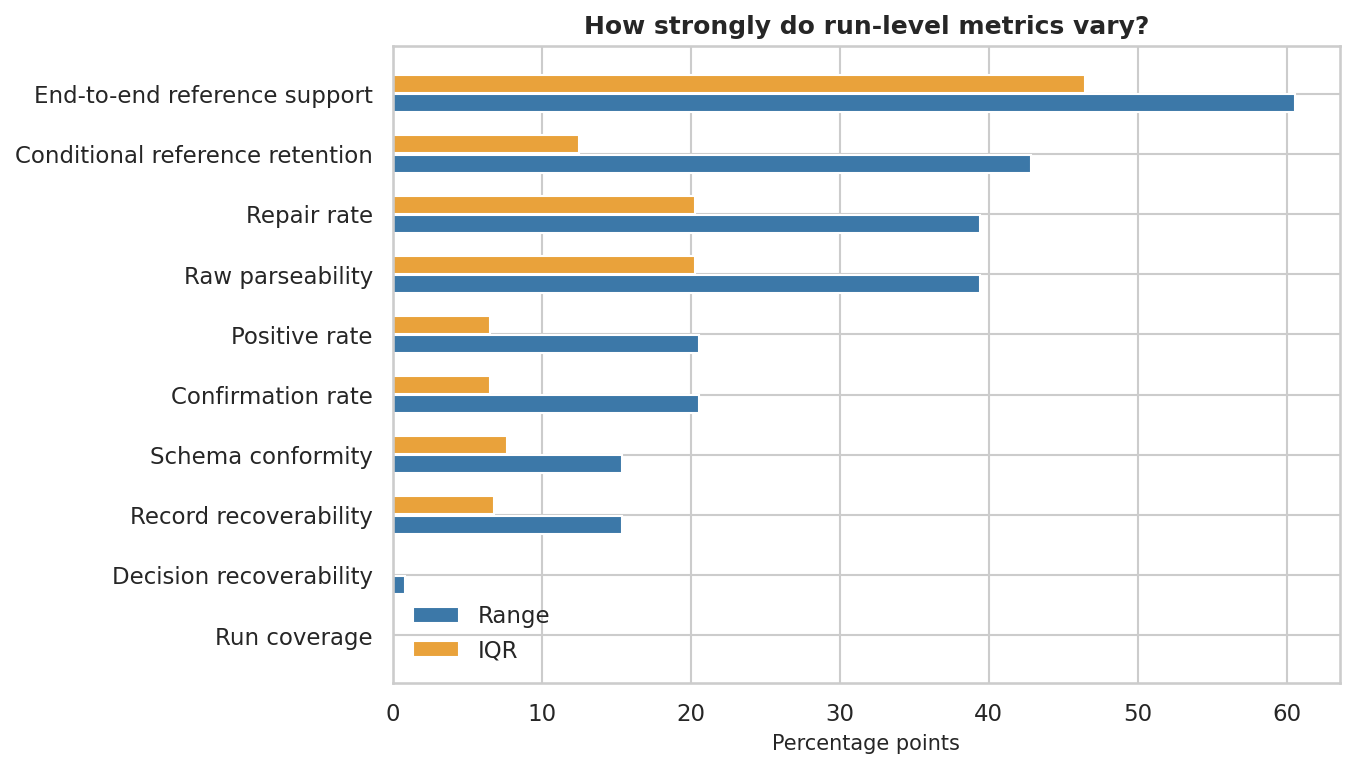

In [18]:
metric_names = {
    "run_coverage": "Run coverage", "raw_parseability": "Raw parseability",
    "decision_recoverability": "Decision recoverability", "record_recoverability": "Record recoverability",
    "schema_conformity": "Schema conformity", "repair_rate": "Repair rate",
    "positive_rate": "Positive rate", "confirmation_rate": "Confirmation rate",
    "exact_stage2_conditional_retention": "Conditional reference retention",
    "exact_end_to_end_reference_support": "End-to-end reference support",
}
profile = analysis["metric_profile"].copy()
profile["Metric"] = profile["metric"].map(metric_names)
profile_display = profile[["Metric", "applicable_runs", "minimum", "maximum", "range", "iqr", "unique_values"]].rename(columns={
    "applicable_runs": "Applicable runs", "minimum": "Minimum", "maximum": "Maximum",
    "range": "Range", "iqr": "IQR", "unique_values": "Unique values",
})
display(show_table(profile_display, percent_cols=["Minimum", "Maximum", "Range", "IQR"], caption="Metric applicability and empirical discrimination"))

fig, ax = plt.subplots(figsize=(9.2, 5.3))
ordered = profile.sort_values("range")
y = np.arange(len(ordered))
ax.barh(y - .16, ordered["range"] * 100, height=.3, label="Range", color=COLORS["stage1"])
ax.barh(y + .16, ordered["iqr"] * 100, height=.3, label="IQR", color=COLORS["repair"])
ax.set_yticks(y, ordered["Metric"])
ax.set_xlabel("Percentage points")
ax.set_title("How strongly do run-level metrics vary?")
ax.legend()
fig.tight_layout()
save_figure(fig, "14_metric_discrimination.png")


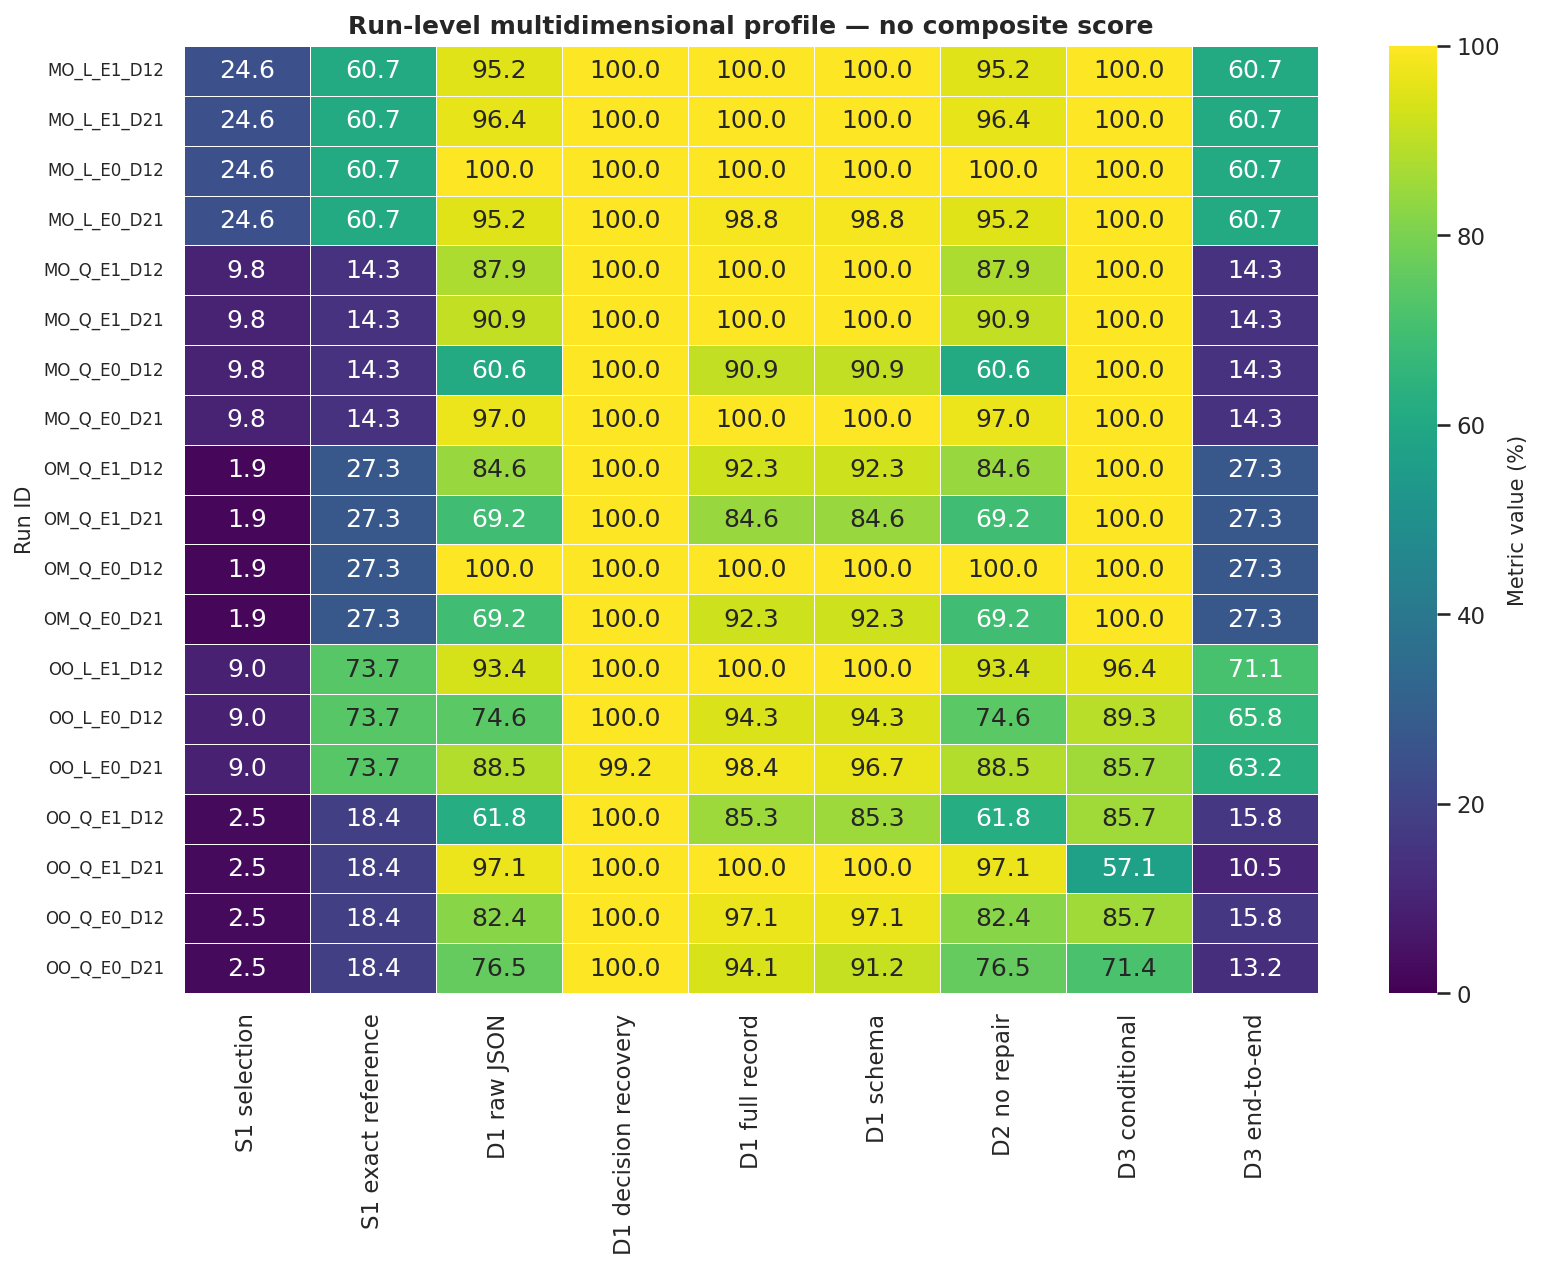

In [19]:
consolidated = s2.merge(
    s1[["ontology_pair", "stage1_model", "candidate_selection_rate", "exact_reference_coverage"]],
    on=["ontology_pair", "stage1_model"], how="left",
).set_index("run_id")
consolidated_profile = pd.DataFrame({
    "S1 selection": consolidated["candidate_selection_rate"],
    "S1 exact reference": consolidated["exact_reference_coverage"],
    "D1 raw JSON": consolidated["raw_parseability"],
    "D1 decision recovery": consolidated["decision_recoverability"],
    "D1 full record": consolidated["record_recoverability"],
    "D1 schema": consolidated["schema_conformity"],
    "D2 no repair": 1 - consolidated["repair_rate"],
    "D3 conditional": consolidated["exact_stage2_conditional_retention"],
    "D3 end-to-end": consolidated["exact_end_to_end_reference_support"],
})
fig, ax = plt.subplots(figsize=(12.2, 8.2))
sns.heatmap(consolidated_profile * 100, annot=True, fmt=".1f", cmap="viridis", vmin=0, vmax=100,
            cbar_kws={"label": "Metric value (%)"}, linewidths=.35, ax=ax)
ax.set_title("Run-level multidimensional profile — no composite score")
ax.set_xlabel("")
ax.set_ylabel("Run ID")
ax.tick_params(axis="y", rotation=0, labelsize=8)
save_figure(fig, "15_multidimensional_run_profile.png")


## 10. Evidence summary and paper claim boundaries

The table below is generated from the evaluated artefacts and maps the evidence directly to the **three final paper RQs**. It distinguishes observed evidence, defensible interpretation, and claims that are not supported by the current archive.


In [20]:
overlap_min, overlap_max = analysis["candidate_overlap"]["jaccard"].agg(["min", "max"])
s1_llama = s1[s1["stage1_model"] == "Llama"]["exact_reference_coverage"]
s1_qwen = s1[s1["stage1_model"] == "Qwen"]["exact_reference_coverage"]
repair_min, repair_max = s2["repair_rate"].agg(["min", "max"])
cond_min, cond_max = s2["exact_stage2_conditional_retention"].agg(["min", "max"])
e2e_min, e2e_max = s2["exact_end_to_end_reference_support"].agg(["min", "max"])
d4_core = comparisons[comparisons["comparison_type"].isin(["direction", "examples"])]
agree_min, agree_max = d4_core["agreement"].agg(["min", "max"])
usable = int(analysis["stage2_manifest"]["analysis_included"].sum())
planned = len(analysis["stage2_manifest"])
repeated = int(analysis["stage2_rows"].loc[analysis["stage2_rows"]["analysis_included"], "repeated_json"].sum())
ambiguous_rel = int(analysis["stage2_rows"].loc[analysis["stage2_rows"]["analysis_included"], "ambiguous_relationship"].sum())
conflicting = int(analysis["stage2_rows"].loc[analysis["stage2_rows"]["analysis_included"], "conflicting_decision"].sum())

rq_summary = pd.DataFrame([
    ["RQ1", f"Conditional exact-reference retention spans {cond_min:.1%}–{cond_max:.1%}; end-to-end support spans {e2e_min:.1%}–{e2e_max:.1%} and is bounded by Stage 1 coverage.",
     "Supported-pair loss can be localised across Stage 1 and Stage 2; Stage 2 cannot recover a supported pair removed by Stage 1.",
     "Do not treat unlisted pairs as false positives or a positive Stage 2 decision as exact free-text predicate correctness."],
    ["RQ2", f"Candidate-set Jaccard spans {overlap_min:.3f}–{overlap_max:.3f}; exact S1 reference coverage spans {s1_llama.min():.1%}–{s1_llama.max():.1%} for Llama and {s1_qwen.min():.1%}–{s1_qwen.max():.1%} for Qwen; direction/example agreement spans {agree_min:.1%}–{agree_max:.1%}.",
     "Stage 1 selector choice materially changes the search space; Stage 2 direction and example conditions change a smaller but meaningful subset of binary decisions.",
     "Do not call the larger candidate set globally more accurate or claim a Stage 2 Llama-versus-Qwen comparison."],
    ["RQ3", f"Repair rate spans {repair_min:.1%}–{repair_max:.1%}; {repeated} rows contain repeated JSON, {ambiguous_rel} have divergent positive relation strings, and {conflicting} has conflicting decisions.",
     "Technical accessibility, record recovery, semantic reference support, and robustness expose different quality layers and should remain separately inspectable.",
     "Do not equate deterministic extraction with semantic correction or infer metric independence solely from different empirical ranges."],
    ["Scope", f"{usable} of {planned} planned Stage 2 cells are usable; the Stage 2 model is constant across archived runs.",
     "The design supports condition-specific and Stage 1-selector comparisons where corresponding cells exist.",
     "Do not claim a balanced factorial experiment or reconstruct missing/inconsistent cells."],
], columns=["Question", "Observed evidence", "Defensible interpretation", "Do not claim"])
display(show_table(rq_summary, caption="Paper-ready evidence and claim boundaries"))


Question,Observed evidence,Defensible interpretation,Do not claim
RQ1,Conditional exact-reference retention spans 57.1%–100.0%; end-to-end support spans 10.5%–71.1% and is bounded by Stage 1 coverage.,Supported-pair loss can be localised across Stage 1 and Stage 2; Stage 2 cannot recover a supported pair removed by Stage 1.,Do not treat unlisted pairs as false positives or a positive Stage 2 decision as exact free-text predicate correctness.
RQ2,Candidate-set Jaccard spans 0.126–0.267; exact S1 reference coverage spans 60.7%–73.7% for Llama and 14.3%–27.3% for Qwen; direction/example agreement spans 84.8%–100.0%.,Stage 1 selector choice materially changes the search space; Stage 2 direction and example conditions change a smaller but meaningful subset of binary decisions.,Do not call the larger candidate set globally more accurate or claim a Stage 2 Llama-versus-Qwen comparison.
RQ3,"Repair rate spans 0.0%–39.4%; repeated JSON, divergent positive relation strings, and conflicting decisions are tracked separately.","Technical accessibility, record recovery, semantic reference support, and robustness expose different quality layers and should remain separately inspectable.",Do not equate deterministic extraction with semantic correction or infer metric independence solely from different empirical ranges.
Scope,19 of 24 planned Stage 2 cells are usable; the Stage 2 model is constant across archived runs.,The design supports condition-specific and Stage 1-selector comparisons where corresponding cells exist.,Do not claim a balanced factorial experiment or reconstruct missing/inconsistent cells.


## 11. Exported artefacts

All tables used above are exported as CSV, including the raw-record audit, exact and sensitivity reference sets, run manifest, detailed reference fates, and the manual direction-review queue. Every figure is saved as a publication-ready PNG. The notebook retains the original raw Stage&nbsp;2 responses unchanged in the packaged `data/` directory.

This three-RQ version changes the **narrative organisation and paper mapping only**. The underlying calculations, included/excluded run decisions, metric definitions, and previously executed analysis outputs are preserved.


In [21]:
export_inventory = []
for path in sorted(TABLE_DIR.glob("*.csv")):
    export_inventory.append(["Table", path.name, path.stat().st_size])
for path in sorted(FIGURE_DIR.glob("*.png")):
    export_inventory.append(["Figure", path.name, path.stat().st_size])
inventory = pd.DataFrame(export_inventory, columns=["Type", "File", "Bytes"])
display(show_table(inventory, caption=f"Export inventory: {len(inventory)} files"))
display(callout(
    "Reproducibility status",
    "The analysis completed from the packaged OWL, ODS, CSV, and JSON artefacts. "
    "No old evaluation outputs were used, no missing run was reconstructed, and excluded cells remain visible in the manifest.",
    color=COLORS["structural"],
))


Type,File,Bytes
Table,data_file_manifest.csv,10485
Table,direction_review_queue.csv,292882
Table,exact_reference_fates.csv,115259
Table,expanded_reference_fates.csv,145319
Table,ground_truth_audit.csv,640
Table,ground_truth_grouped_rows.csv,11578
Table,metric_diagnostics.csv,949
Table,ontology_evidence_profile.csv,459
Table,raw_output_record_audit.csv,494870
Table,reference_pairs_exact.csv,25530


HTMLBlock()